# 2-Stage PhoBERT-BiLSTM-Mask-aware TC-LSTM for Vietnamese ABSA

Pipeline :

```text
Input sentence
↓
Fine-tuned Fine-tuned PhoBERT encoder
↓
Stage 1: BiLSTM ATE/evidence mask + weighted BIO loss
↓
Aspect-specific threshold tuning
↓
Stage 2: Mixed gold/predicted mask training
↓
Target-aware attention + local-context TC-LSTM
↓
Stage 2 cost-sensitive CE + neutral-threshold calibration
↓
aspect#polarity
```

Notebook này Stage 2 cải thiện neutral bằng **cost-sensitive CrossEntropy** và **tune ngưỡng neutral trên dev set**.


In [1]:
from google.colab import drive
import shutil
from datetime import datetime

#Kết nối Drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!pip -q install transformers accelerate scikit-learn seqeval sentencepiece tqdm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 2.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


In [3]:
import os
import re
import json
import copy
import random
from typing import List, Dict, Tuple, Optional, Union
from collections import Counter

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW

from transformers import AutoTokenizer, AutoModel
from tqdm.auto import tqdm
from IPython.display import display

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from seqeval.metrics import classification_report as seqeval_report


In [4]:
os.environ['TOKENIZERS_PARALLELISM'] = 'false'

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

Device: cuda


In [5]:
MODEL_NAME = 'vinai/phobert-base'
BACKBONE_NAME = 'Fine-tuned PhoBERT'
MAX_LEN = 192

FAST_DEBUG = False
DEBUG_TRAIN_SIZE = 400
DEBUG_DEV_SIZE = 100
DEBUG_TEST_SIZE = 100

BATCH_SIZE_ATE = 8
BATCH_SIZE_ACSC = 8
EPOCHS_ATE = 4
EPOCHS_ACSC = 4

# Differential learning rate: encoder nhỏ, task head lớn hơn.
LR_ENCODER = 2e-5
LR_ATE_HEAD = 1e-3
LR_ACSC_HEAD = 5e-4
WEIGHT_DECAY = 1e-4

LSTM_HIDDEN = 128
DROPOUT = 0.3

# Fine-tune nhẹ để tránh overfit và giảm RAM/VRAM.
UNFREEZE_LAST_N_LAYERS = 4
UNFREEZE_EMBEDDINGS = False

# Stage 1 threshold tuning.
DEFAULT_EVIDENCE_THRESHOLD = 0.45
THRESHOLD_GRID = [0.20, 0.25, 0.30, 0.35, 0.40, 0.45, 0.50, 0.55, 0.60, 0.70]
EVIDENCE_THRESHOLD = DEFAULT_EVIDENCE_THRESHOLD
EVIDENCE_THRESHOLDS_BY_ASPECT = None

# Stage 2 robustness: train bằng cả gold mask và predicted mask từ Stage 1.
USE_MIXED_STAGE2_MASK = True
PREDICTED_MASK_RATIO = 0.50

# Target-aware attention chỉ attend vùng local quanh evidence mask.
LOCAL_CONTEXT_WINDOW = 2

# Stage 2: không oversampling/focal/lexicon; chỉ dùng cost-sensitive loss + threshold calibration.
USE_STAGE2_CLASS_WEIGHTS = True
STAGE2_CLASS_WEIGHT_POWER = 0.50     # 0.5 = inverse sqrt frequency, nhẹ hơn inverse frequency.
STAGE2_CLASS_WEIGHT_CLIP = (0.50, 3.00)

# Tune ngưỡng neutral trên dev set để bắt neutral tốt hơn nhưng vẫn giữ macro-F1.
TUNE_STAGE2_NEUTRAL_THRESHOLD = True
NEUTRAL_THRESHOLD_GRID = [0.10, 0.12, 0.14, 0.16, 0.18, 0.20, 0.22, 0.24, 0.26, 0.28,
                          0.30, 0.32, 0.34, 0.36, 0.38, 0.40, 0.42, 0.44, 0.46, 0.48,
                          0.50, 0.55, 0.60]
BEST_NEUTRAL_THRESHOLD = None


## 1. Load UIT-ViSD4SA

In [6]:
!rm -rf UIT-ViSD4SA
!git clone -q https://github.com/kimkim00/UIT-ViSD4SA.git

DATA_DIR = '/content/UIT-ViSD4SA/data'
print(os.listdir(DATA_DIR))

['dev.jsonl', 'test.jsonl', 'train.jsonl']


In [7]:
POLARITY_ALIASES = {
    'pos': 'positive', 'positive': 'positive', '+': 'positive', '1': 'positive',
    'neg': 'negative', 'negative': 'negative', '-': 'negative', '0': 'negative',
    'neu': 'neutral', 'neutral': 'neutral', '2': 'neutral',
    'conflict': 'conflict', 'mixed': 'conflict',
}


def normalize_polarity(x: str) -> str:
    s = str(x).strip().lower().replace(' ', '').replace('_', '').replace('-', '')
    for k, v in POLARITY_ALIASES.items():
        if s == k.replace('_', '').replace('-', ''):
            return v
    if 'pos' in s:
        return 'positive'
    if 'neg' in s:
        return 'negative'
    if 'neu' in s:
        return 'neutral'
    if 'conflict' in s or 'mixed' in s:
        return 'conflict'
    return str(x).strip().lower()


def normalize_category(x: str) -> str:
    s = str(x).strip()
    s = re.sub(r'[^A-Za-z0-9_À-ỹ]+', '_', s)
    return re.sub(r'_+', '_', s).strip('_').upper()

In [8]:
def split_category_polarity(label: str) -> Tuple[str, str]:
    raw = str(label).strip()
    for sep in ['#', '|', ';', ':']:
        if sep in raw:
            parts = [p.strip() for p in raw.split(sep) if p.strip()]
            if len(parts) >= 2:
                return normalize_category(parts[0]), normalize_polarity(parts[-1])

    low = raw.lower()
    for token in ['positive', 'negative', 'neutral', 'conflict', 'pos', 'neg', 'neu']:
        if token in low:
            cat = re.sub(token, '', raw, flags=re.IGNORECASE)
            cat = cat.replace('#', ' ').replace('-', ' ').replace('_', ' ')
            return normalize_category(cat), normalize_polarity(token)

    return normalize_category(raw), 'unknown'

In [9]:
def parse_one_label(item) -> Optional[Dict]:
    try:
        if isinstance(item, dict):
            start = item.get('start', item.get('from', item.get('begin', item.get('s'))))
            end = item.get('end', item.get('to', item.get('finish', item.get('e'))))
            label = item.get('label', item.get('labels', item.get('tag', item.get('category'))))
            if isinstance(label, list) and label:
                label = label[0]
        elif isinstance(item, (list, tuple)) and len(item) >= 3:
            start, end, label = item[0], item[1], item[2]
        else:
            return None

        start, end = int(start), int(end)
        if end <= start:
            return None
        category, polarity = split_category_polarity(label)
        return {'start': start, 'end': end, 'label': str(label), 'category': category, 'polarity': polarity}
    except Exception:
        return None

In [10]:
def read_jsonl(path: str) -> List[Dict]:
    rows = []
    with open(path, 'r', encoding='utf-8') as f:
        for line in f:
            if not line.strip():
                continue
            obj = json.loads(line)
            text = obj.get('text', obj.get('sentence', obj.get('comment', '')))
            raw_labels = obj.get('labels', obj.get('spans', []))
            spans = []
            for item in raw_labels:
                sp = parse_one_label(item)
                if sp is None:
                    continue
                sp['start'] = max(0, min(sp['start'], len(text)))
                sp['end'] = max(0, min(sp['end'], len(text)))
                if sp['end'] > sp['start']:
                    sp['span_text'] = text[sp['start']:sp['end']]
                    spans.append(sp)
            rows.append({'text': text, 'labels': spans})
    return rows

In [11]:
train_raw = read_jsonl(os.path.join(DATA_DIR, 'train.jsonl'))
dev_raw = read_jsonl(os.path.join(DATA_DIR, 'dev.jsonl'))
test_raw = read_jsonl(os.path.join(DATA_DIR, 'test.jsonl'))

if FAST_DEBUG:
    train_raw = train_raw[:DEBUG_TRAIN_SIZE]
    dev_raw = dev_raw[:DEBUG_DEV_SIZE]
    test_raw = test_raw[:DEBUG_TEST_SIZE]

print(len(train_raw), len(dev_raw), len(test_raw))
print(json.dumps(train_raw[0], ensure_ascii=False, indent=2)[:1200])

7785 1112 2225
{
  "text": "Pin Sài tầm 50h cho pin 100/100. Camera ổn ... tất cả đều OK ... nhân viên thế giới di động trần văn thời cà mau nhiệt tình và vui vẻ ...chúc các ae sức khỏe tốt và phục ok hoài nha....",
  "labels": [
    {
      "start": 0,
      "end": 31,
      "label": "BATTERY#POSITIVE",
      "category": "BATTERY",
      "polarity": "positive",
      "span_text": "Pin Sài tầm 50h cho pin 100/100"
    },
    {
      "start": 33,
      "end": 42,
      "label": "CAMERA#POSITIVE",
      "category": "CAMERA",
      "polarity": "positive",
      "span_text": "Camera ổn"
    },
    {
      "start": 47,
      "end": 60,
      "label": "GENERAL#POSITIVE",
      "category": "GENERAL",
      "polarity": "positive",
      "span_text": "tất cả đều OK"
    },
    {
      "start": 65,
      "end": 181,
      "label": "SER&ACC#POSITIVE",
      "category": "SER_ACC",
      "polarity": "positive",
      "span_text": "nhân viên thế giới di động trần văn thời cà mau nhiệt tình và vui vẻ

In [12]:
all_spans = [s for r in train_raw + dev_raw + test_raw for s in r['labels']]
print('Num spans:', len(all_spans))
print('Categories:', Counter(s['category'] for s in all_spans).most_common())
print('Polarities:', Counter(s['polarity'] for s in all_spans).most_common())

Num spans: 35396
Categories: [('GENERAL', 8057), ('PERFORMANCE', 6906), ('BATTERY', 5630), ('FEATURES', 3994), ('CAMERA', 3117), ('SER_ACC', 2635), ('DESIGN', 2141), ('PRICE', 1389), ('SCREEN', 1382), ('STORAGE', 145)]
Polarities: [('positive', 21832), ('negative', 11350), ('neutral', 2214)]


## 2. Labels và tokenizer

In [13]:
CATEGORIES = sorted({s['category'] for r in train_raw + dev_raw + test_raw for s in r['labels']})
TAG_LIST = ['O']
for cat in CATEGORIES:
    TAG_LIST += [f'B-{cat}', f'I-{cat}']

tag2id = {t: i for i, t in enumerate(TAG_LIST)}
id2tag = {i: t for t, i in tag2id.items()}

POLARITIES = sorted({s['polarity'] for r in train_raw + dev_raw + test_raw for s in r['labels'] if s['polarity'] != 'unknown'})
pol2id = {p: i for i, p in enumerate(POLARITIES)}
id2pol = {i: p for p, i in pol2id.items()}

aspect2id = {a: i for i, a in enumerate(CATEGORIES)}
id2aspect = {i: a for a, i in aspect2id.items()}

print('Num BIO tags:', len(TAG_LIST))
print('Polarities:', pol2id)
print('Aspects:', aspect2id)

Num BIO tags: 21
Polarities: {'negative': 0, 'neutral': 1, 'positive': 2}
Aspects: {'BATTERY': 0, 'CAMERA': 1, 'DESIGN': 2, 'FEATURES': 3, 'GENERAL': 4, 'PERFORMANCE': 5, 'PRICE': 6, 'SCREEN': 7, 'SER_ACC': 8, 'STORAGE': 9}


In [14]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, use_fast=False)
print('Backbone:', BACKBONE_NAME)
print('Tokenizer tokens:', tokenizer.cls_token, tokenizer.sep_token, tokenizer.pad_token)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:124: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/557 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/895k [00:00<?, ?B/s]

bpe.codes:   0%|          | 0.00/1.14M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/3.13M [00:00<?, ?B/s]

Backbone: Fine-tuned PhoBERT
Tokenizer tokens: <s> </s> <pad>


In [15]:
WORD_RE = re.compile(r'\S+')


def get_word_spans(text: str):
    return [(m.group(0), m.start(), m.end()) for m in WORD_RE.finditer(text)]


def word_bio_labels(text: str, spans: List[Dict]) -> List[str]:
    words = get_word_spans(text)
    labels = ['O'] * len(words)

    for sp in sorted(spans, key=lambda x: (x['start'], x['end'])):
        cat = sp['category']
        inside = []
        for i, (_, ws, we) in enumerate(words):
            if ws < sp['end'] and we > sp['start']:
                inside.append(i)
        for j, idx in enumerate(inside):
            labels[idx] = f'B-{cat}' if j == 0 else f'I-{cat}'

    return labels

In [16]:
def manual_encode(
    text: str,
    spans: Optional[List[Dict]] = None,
    target_spans: Optional[List[Tuple[int, int]]] = None,
    max_len: int = MAX_LEN,
    return_labels: bool = False,
    return_evidence_mask: bool = False,
):
    word_spans = get_word_spans(text)
    word_labels = word_bio_labels(text, spans or []) if return_labels else None
    target_spans = target_spans or []

    sub_tokens, sub_offsets, sub_evidence = [], [], []
    sub_labels = []

    for wi, (word, ws, we) in enumerate(word_spans):
        toks = tokenizer.tokenize(word) or [tokenizer.unk_token]
        w_label = word_labels[wi] if word_labels is not None else 'O'
        in_evidence = any(ws < te and we > ts for ts, te in target_spans)

        for k, tok in enumerate(toks):
            sub_tokens.append(tok)
            sub_offsets.append((ws, we))
            sub_evidence.append(1.0 if in_evidence else 0.0)

            if return_labels:
                lab = 'I-' + w_label[2:] if k > 0 and w_label.startswith('B-') else w_label
                sub_labels.append(tag2id.get(lab, tag2id['O']))

    sub_tokens = sub_tokens[:max_len - 2]
    sub_offsets = sub_offsets[:max_len - 2]
    sub_evidence = sub_evidence[:max_len - 2]
    if return_labels:
        sub_labels = sub_labels[:max_len - 2]

    input_ids = [tokenizer.cls_token_id] + tokenizer.convert_tokens_to_ids(sub_tokens) + [tokenizer.sep_token_id]
    attention_mask = [1] * len(input_ids)
    offsets = [(-1, -1)] + sub_offsets + [(-1, -1)]
    evidence_mask = [0.0] + sub_evidence + [0.0]
    labels = [-100] + sub_labels + [-100] if return_labels else None

    pad_len = max_len - len(input_ids)
    if pad_len > 0:
        input_ids += [tokenizer.pad_token_id] * pad_len
        attention_mask += [0] * pad_len
        offsets += [(-1, -1)] * pad_len
        evidence_mask += [0.0] * pad_len
        if return_labels:
            labels += [-100] * pad_len

    out = {
        'input_ids': torch.tensor(input_ids, dtype=torch.long),
        'attention_mask': torch.tensor(attention_mask, dtype=torch.long),
        'offsets': offsets,
    }
    if return_labels:
        out['labels'] = torch.tensor(labels, dtype=torch.long)
    if return_evidence_mask:
        out['evidence_mask'] = torch.tensor(evidence_mask, dtype=torch.float)
    return out

In [17]:
sample = train_raw[0]
enc = manual_encode(sample['text'], sample['labels'], return_labels=True)
print(sample['text'])
for i in range(20):
    if int(enc['attention_mask'][i]) == 0:
        break
    tok = tokenizer.convert_ids_to_tokens([int(enc['input_ids'][i])])[0]
    lab = int(enc['labels'][i])
    print(i, tok, id2tag[lab] if lab != -100 else 'SPECIAL')

Pin Sài tầm 50h cho pin 100/100. Camera ổn ... tất cả đều OK ... nhân viên thế giới di động trần văn thời cà mau nhiệt tình và vui vẻ ...chúc các ae sức khỏe tốt và phục ok hoài nha....
0 <s> SPECIAL
1 Pin B-BATTERY
2 Sài I-BATTERY
3 tầm I-BATTERY
4 50@@ I-BATTERY
5 h I-BATTERY
6 cho I-BATTERY
7 pin I-BATTERY
8 100@@ I-BATTERY
9 /@@ I-BATTERY
10 100@@ I-BATTERY
11 . I-BATTERY
12 Camera B-CAMERA
13 ổn I-CAMERA
14 ... O
15 tất B-GENERAL
16 cả I-GENERAL
17 đều I-GENERAL
18 OK I-GENERAL
19 ... O


## 3. Dataset và DataLoader

In [18]:
class ATEDataset(Dataset):
    def __init__(self, rows, max_len=MAX_LEN):
        self.rows = rows
        self.max_len = max_len

    def __len__(self):
        return len(self.rows)

    def __getitem__(self, idx):
        row = self.rows[idx]
        enc = manual_encode(row['text'], row['labels'], max_len=self.max_len, return_labels=True)
        return {
            'input_ids': enc['input_ids'],
            'attention_mask': enc['attention_mask'],
            'labels': enc['labels'],
        }

In [19]:
def make_acsc_samples(rows: List[Dict]) -> List[Dict]:
    samples = []
    for row in rows:
        text = row['text']
        for sp in row['labels']:
            if sp['polarity'] not in pol2id:
                continue
            samples.append({
                'text': text,
                'category': sp['category'],
                'start': sp['start'],
                'end': sp['end'],
                'span_text': text[sp['start']:sp['end']],
                'label': pol2id[sp['polarity']],
            })
    return samples

acsc_train_samples = make_acsc_samples(train_raw)
acsc_dev_samples = make_acsc_samples(dev_raw)
acsc_test_samples = make_acsc_samples(test_raw)

print(len(acsc_train_samples), len(acsc_dev_samples), len(acsc_test_samples))
print(json.dumps(acsc_train_samples[0], ensure_ascii=False, indent=2))

24771 3582 7043
{
  "text": "Pin Sài tầm 50h cho pin 100/100. Camera ổn ... tất cả đều OK ... nhân viên thế giới di động trần văn thời cà mau nhiệt tình và vui vẻ ...chúc các ae sức khỏe tốt và phục ok hoài nha....",
  "category": "BATTERY",
  "start": 0,
  "end": 31,
  "span_text": "Pin Sài tầm 50h cho pin 100/100",
  "label": 2
}


In [20]:
class ACSCMaskDataset(Dataset):
    def __init__(self, samples, max_len=MAX_LEN):
        self.samples = samples
        self.max_len = max_len

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        s = self.samples[idx]
        enc = manual_encode(
            s['text'],
            target_spans=[(s['start'], s['end'])],
            max_len=self.max_len,
            return_evidence_mask=True,
        )
        return {
            'input_ids': enc['input_ids'],
            'attention_mask': enc['attention_mask'],
            'evidence_mask': enc['evidence_mask'],
            'aspect_id': torch.tensor(aspect2id[s['category']], dtype=torch.long),
            'labels': torch.tensor(s['label'], dtype=torch.long),
        }

In [21]:
ate_train_ds = ATEDataset(train_raw)
ate_dev_ds = ATEDataset(dev_raw)
ate_test_ds = ATEDataset(test_raw)

# Stage 2 dev/test dùng gold evidence mask để đánh giá standalone polarity.
# Stage 2 train loader sẽ được tạo sau khi Stage 1 train xong để có predicted mask.
acsc_dev_ds = ACSCMaskDataset(acsc_dev_samples)
acsc_test_ds = ACSCMaskDataset(acsc_test_samples)


In [22]:
ate_train_loader = DataLoader(ate_train_ds, batch_size=BATCH_SIZE_ATE, shuffle=True)
ate_dev_loader = DataLoader(ate_dev_ds, batch_size=BATCH_SIZE_ATE, shuffle=False)
ate_test_loader = DataLoader(ate_test_ds, batch_size=BATCH_SIZE_ATE, shuffle=False)

acsc_dev_loader = DataLoader(acsc_dev_ds, batch_size=BATCH_SIZE_ACSC, shuffle=False)
acsc_test_loader = DataLoader(acsc_test_ds, batch_size=BATCH_SIZE_ACSC, shuffle=False)


## 4. Fine-tuned Fine-tuned PhoBERT encoder


In [23]:
def get_transformer_layers(model):
    """Return transformer block list for common HuggingFace encoder architectures."""
    candidates = [
        ('encoder.layer', getattr(getattr(model, 'encoder', None), 'layer', None)),
        ('roberta.encoder.layer', getattr(getattr(getattr(model, 'roberta', None), 'encoder', None), 'layer', None)),
        ('bert.encoder.layer', getattr(getattr(getattr(model, 'bert', None), 'encoder', None), 'layer', None)),
        ('deberta.encoder.layer', getattr(getattr(getattr(model, 'deberta', None), 'encoder', None), 'layer', None)),
    ]
    for name, layers in candidates:
        if layers is not None:
            return name, layers
    return None, None


class FineTunedTransformerEncoder(nn.Module):
    def __init__(self, model_name: str, unfreeze_last_n_layers: int = 4, unfreeze_embeddings: bool = False):
        super().__init__()
        self.model = AutoModel.from_pretrained(model_name)

        # Freeze toàn bộ trước, sau đó chỉ mở một vài layer cuối.
        for p in self.model.parameters():
            p.requires_grad = False

        layer_name, layers = get_transformer_layers(self.model)
        if layers is not None:
            for layer in layers[-unfreeze_last_n_layers:]:
                for p in layer.parameters():
                    p.requires_grad = True
            print(f'Unfrozen last {unfreeze_last_n_layers} transformer layers from: {layer_name}')
        else:
            # Fallback: nếu architecture lạ thì mở toàn bộ encoder.
            print('Warning: cannot find transformer layers; unfreezing the whole encoder.')
            for p in self.model.parameters():
                p.requires_grad = True

        if unfreeze_embeddings and hasattr(self.model, 'embeddings'):
            for p in self.model.embeddings.parameters():
                p.requires_grad = True

        if hasattr(self.model, 'pooler') and self.model.pooler is not None:
            for p in self.model.pooler.parameters():
                p.requires_grad = True

    def forward(self, input_ids, attention_mask):
        out = self.model(input_ids=input_ids, attention_mask=attention_mask)
        return out.last_hidden_state


def count_trainable_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


def build_differential_optimizer(model, encoder_lr, head_lr, weight_decay=1e-4):
    encoder_params, head_params = [], []
    for name, p in model.named_parameters():
        if not p.requires_grad:
            continue
        if name.startswith('encoder.model'):
            encoder_params.append(p)
        else:
            head_params.append(p)

    groups = []
    if encoder_params:
        groups.append({'params': encoder_params, 'lr': encoder_lr})
    if head_params:
        groups.append({'params': head_params, 'lr': head_lr})

    return AdamW(groups, weight_decay=weight_decay)


In [24]:
encoder_stage1 = FineTunedTransformerEncoder(
    MODEL_NAME,
    unfreeze_last_n_layers=UNFREEZE_LAST_N_LAYERS,
    unfreeze_embeddings=UNFREEZE_EMBEDDINGS,
).to(device)

print('Encoder hidden size:', encoder_stage1.model.config.hidden_size)
print('Stage 1 encoder trainable params:', count_trainable_params(encoder_stage1))


pytorch_model.bin:   0%|          | 0.00/543M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/543M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] RobertaModel LOAD REPORT from: vinai/phobert-base
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.bias              | UNEXPECTED |  | 
lm_head.decoder.bias      | UNEXPECTED |  | 
lm_head.dense.bias        | UNEXPECTED |  | 
lm_head.dense.weight      | UNEXPECTED |  | 
lm_head.decoder.weight    | UNEXPECTED |  | 
lm_head.layer_norm.weight | UNEXPECTED |  | 
lm_head.layer_norm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Unfrozen last 4 transformer layers from: encoder.layer
Encoder hidden size: 768
Stage 1 encoder trainable params: 28942080


## 5. Stage 1: encoder embeddings → BiLSTM ATE mask


In [25]:
def build_ate_tag_weights(rows, max_len=MAX_LEN):
    """Weighted CE cho BIO tagging: giảm áp đảo của nhãn O, tăng trọng số B/I aspect."""
    counts = np.zeros(len(TAG_LIST), dtype=np.float64)

    for row in tqdm(rows, desc='Build ATE tag weights'):
        enc = manual_encode(row['text'], row['labels'], max_len=max_len, return_labels=True)
        labels = enc['labels'].numpy()
        for y in labels:
            if y != -100:
                counts[int(y)] += 1

    weights = 1.0 / np.sqrt(np.maximum(counts, 1.0))
    weights = weights / weights.mean()

    # Không để nhãn O quá nhỏ vì vẫn cần học boundary ổn định.
    weights[tag2id['O']] = min(weights[tag2id['O']], 0.50)
    weights = weights / weights.mean()

    return torch.tensor(weights, dtype=torch.float)


class BiLSTMATE(nn.Module):
    def __init__(self, encoder, num_tags, hidden=128, dropout=0.3, tag_weights=None):
        super().__init__()
        self.encoder = encoder
        h_size = encoder.model.config.hidden_size
        self.lstm = nn.LSTM(h_size, hidden, batch_first=True, bidirectional=True)
        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(hidden * 2, num_tags)
        self.loss_fn = nn.CrossEntropyLoss(ignore_index=-100, weight=tag_weights)

    def forward(self, input_ids, attention_mask, labels=None):
        h = self.encoder(input_ids, attention_mask)
        out, _ = self.lstm(h)
        logits = self.classifier(self.dropout(out))
        loss = None
        if labels is not None:
            loss = self.loss_fn(logits.view(-1, logits.size(-1)), labels.view(-1))
        return {'loss': loss, 'logits': logits}


In [26]:
ate_tag_weights = build_ate_tag_weights(train_raw).to(device)
print('ATE tag weights sample:', ate_tag_weights[:10].detach().cpu().numpy())

stage1_ate = BiLSTMATE(
    encoder_stage1,
    num_tags=len(TAG_LIST),
    hidden=LSTM_HIDDEN,
    dropout=DROPOUT,
    tag_weights=ate_tag_weights,
).to(device)

print('Stage 1 total trainable params:', count_trainable_params(stage1_ate))


Build ATE tag weights:   0%|          | 0/7785 [00:00<?, ?it/s]

ATE tag weights sample: [0.15021276 0.8158659  0.2768739  1.0972191  0.40522996 1.3255377
 0.49667656 0.97018266 0.3003945  0.68242055]
Stage 1 total trainable params: 29867029


In [27]:
def train_one_epoch_ate(model, loader, optimizer):
    model.train()
    total_loss = 0

    for batch in tqdm(loader, desc='Train ATE'):
        batch = {k: v.to(device) for k, v in batch.items()}
        optimizer.zero_grad()
        out = model(**batch)
        loss = out['loss']
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        total_loss += loss.item()

    return total_loss / len(loader)

In [28]:
@torch.no_grad()
def eval_ate(model, loader):
    model.eval()
    total_loss = 0
    true_tags, pred_tags = [], []

    for batch in tqdm(loader, desc='Eval ATE'):
        batch = {k: v.to(device) for k, v in batch.items()}
        out = model(**batch)
        total_loss += out['loss'].item()

        preds = out['logits'].argmax(dim=-1).detach().cpu().numpy()
        labels = batch['labels'].detach().cpu().numpy()

        for p_seq, y_seq in zip(preds, labels):
            t, p = [], []
            for pi, yi in zip(p_seq, y_seq):
                if yi == -100:
                    continue
                t.append(id2tag[int(yi)])
                p.append(id2tag[int(pi)])
            true_tags.append(t)
            pred_tags.append(p)

    return total_loss / len(loader), true_tags, pred_tags

In [29]:
optimizer = build_differential_optimizer(
    stage1_ate,
    encoder_lr=LR_ENCODER,
    head_lr=LR_ATE_HEAD,
    weight_decay=WEIGHT_DECAY,
)

best_stage1_f1 = -1
best_stage1_state = None

for epoch in range(1, EPOCHS_ATE + 1):
    train_loss = train_one_epoch_ate(stage1_ate, ate_train_loader, optimizer)
    dev_loss, y_true_tags, y_pred_tags = eval_ate(stage1_ate, ate_dev_loader)
    report = seqeval_report(y_true_tags, y_pred_tags, output_dict=True, zero_division=0)
    dev_f1 = report['micro avg']['f1-score']

    print(f'Epoch {epoch} | train_loss={train_loss:.4f} | dev_loss={dev_loss:.4f} | dev_micro_f1={dev_f1:.4f}')

    if dev_f1 > best_stage1_f1:
        best_stage1_f1 = dev_f1
        best_stage1_state = copy.deepcopy(stage1_ate.state_dict())

stage1_ate.load_state_dict(best_stage1_state)
stage1_ate.eval()
print('Best Stage 1 dev micro F1:', best_stage1_f1)


Train ATE:   0%|          | 0/974 [00:00<?, ?it/s]

Eval ATE:   0%|          | 0/139 [00:00<?, ?it/s]

Epoch 1 | train_loss=1.3106 | dev_loss=0.9538 | dev_micro_f1=0.2657


Train ATE:   0%|          | 0/974 [00:00<?, ?it/s]

Eval ATE:   0%|          | 0/139 [00:00<?, ?it/s]

...

Eval ATE:   0%|          | 0/139 [00:00<?, ?it/s]

Epoch 3 | train_loss=0.7562 | dev_loss=0.8067 | dev_micro_f1=0.3538


Train ATE:   0%|          | 0/974 [00:00<?, ?it/s]

Eval ATE:   0%|          | 0/139 [00:00<?, ?it/s]

Epoch 4 | train_loss=0.6473 | dev_loss=0.7768 | dev_micro_f1=0.3896
Best Stage 1 dev micro F1: 0.38964577656675753


In [30]:
test_loss_ate, y_true_tags, y_pred_tags = eval_ate(stage1_ate, ate_test_loader)
print('Stage 1 ATE test loss:', round(test_loss_ate, 4))
print(seqeval_report(y_true_tags, y_pred_tags, zero_division=0))

Eval ATE:   0%|          | 0/279 [00:00<?, ?it/s]

Stage 1 ATE test loss: 0.7643
              precision    recall  f1-score   support

     BATTERY       0.45      0.64      0.53      1114
      CAMERA       0.47      0.66      0.55       616
      DESIGN       0.31      0.55      0.40       410
    FEATURES       0.24      0.43      0.31       821
     GENERAL       0.34      0.54      0.42      1615
 PERFORMANCE       0.24      0.42      0.31      1363
       PRICE       0.17      0.41      0.24       258
      SCREEN       0.30      0.54      0.39       276
     SER_ACC       0.25      0.49      0.33       524
     STORAGE       0.10      0.44      0.17        34

   micro avg       0.31      0.52      0.39      7031
   macro avg       0.29      0.51      0.36      7031
weighted avg       0.32      0.52      0.40      7031



## 6. Stage 1 output: aspect-specific evidence mask

In [31]:
def mask_to_text(text, offsets, mask, threshold=0.5):
    ranges = []
    for (s, e), m in zip(offsets, mask):
        if s < 0 or e < 0 or float(m) < threshold:
            continue
        if not ranges or s > ranges[-1][1] + 1:
            ranges.append([s, e])
        else:
            ranges[-1][1] = max(ranges[-1][1], e)
    return ' | '.join(text[s:e] for s, e in ranges)


def get_valid_token_positions(enc):
    positions = []
    for i, ((s, e), att) in enumerate(zip(enc['offsets'], enc['attention_mask'])):
        if int(att) == 1 and s >= 0 and e >= 0:
            positions.append(i)
    return positions

In [32]:
def resolve_threshold(threshold: Union[float, Dict[str, float], None], category: str) -> float:
    if threshold is None:
        threshold = EVIDENCE_THRESHOLDS_BY_ASPECT if EVIDENCE_THRESHOLDS_BY_ASPECT is not None else DEFAULT_EVIDENCE_THRESHOLD
    if isinstance(threshold, dict):
        return float(threshold.get(category, DEFAULT_EVIDENCE_THRESHOLD))
    return float(threshold)


@torch.no_grad()
def get_stage1_category_max_scores(text: str) -> Dict[str, float]:
    """Cache score cao nhất của từng aspect để tune threshold nhanh hơn."""
    stage1_ate.eval()
    enc = manual_encode(text)
    batch = {
        'input_ids': enc['input_ids'].unsqueeze(0).to(device),
        'attention_mask': enc['attention_mask'].unsqueeze(0).to(device),
    }
    logits = stage1_ate(**batch)['logits'][0]
    probs = torch.softmax(logits, dim=-1).detach().cpu()
    valid_positions = get_valid_token_positions(enc)

    scores_by_cat = {}
    for cat in CATEGORIES:
        b_id = tag2id[f'B-{cat}']
        i_id = tag2id[f'I-{cat}']
        scores = probs[:, b_id] + probs[:, i_id]
        if valid_positions:
            scores_by_cat[cat] = float(scores[valid_positions].max().item())
        else:
            scores_by_cat[cat] = 0.0
    return scores_by_cat


@torch.no_grad()
def predict_evidence_masks(text: str, threshold: Union[float, Dict[str, float], None] = None):
    stage1_ate.eval()
    enc = manual_encode(text)

    batch = {
        'input_ids': enc['input_ids'].unsqueeze(0).to(device),
        'attention_mask': enc['attention_mask'].unsqueeze(0).to(device),
    }

    logits = stage1_ate(**batch)['logits'][0]
    probs = torch.softmax(logits, dim=-1).detach().cpu()
    valid_positions = get_valid_token_positions(enc)

    outputs = []
    for cat in CATEGORIES:
        cat_threshold = resolve_threshold(threshold, cat)
        b_id = tag2id[f'B-{cat}']
        i_id = tag2id[f'I-{cat}']
        scores = probs[:, b_id] + probs[:, i_id]

        mask = torch.zeros(MAX_LEN, dtype=torch.float)
        for pos in valid_positions:
            if float(scores[pos]) >= cat_threshold:
                mask[pos] = float(scores[pos])

        if mask.sum().item() == 0:
            continue

        outputs.append({
            'category': cat,
            'mask': mask,
            'threshold': cat_threshold,
            'confidence': float(mask[mask > 0].mean().item()),
            'evidence_text': mask_to_text(text, enc['offsets'], mask, threshold=cat_threshold),
        })

    return outputs


In [33]:
def prf_from_sets(gold_sets, pred_sets):
    tp = fp = fn = 0
    for gold, pred in zip(gold_sets, pred_sets):
        tp += len(gold & pred)
        fp += len(pred - gold)
        fn += len(gold - pred)
    precision = tp / (tp + fp + 1e-9)
    recall = tp / (tp + fn + 1e-9)
    f1 = 2 * precision * recall / (precision + recall + 1e-9)
    return {'precision': precision, 'recall': recall, 'f1': f1, 'tp': tp, 'fp': fp, 'fn': fn}


def show_metric_table(title, metrics):
    df = pd.DataFrame([{
        'Precision': round(metrics['precision'], 4),
        'Recall': round(metrics['recall'], 4),
        'F1': round(metrics['f1'], 4),
        'TP': metrics['tp'],
        'FP': metrics['fp'],
        'FN': metrics['fn'],
    }])
    print(title)
    display(df)

In [34]:
def eval_stage1_category(rows, threshold):
    gold_sets, pred_sets = [], []
    for row in tqdm(rows, desc='ATE category eval'):
        gold_sets.append(set(sp['category'] for sp in row['labels']))
        pred_sets.append(set(x['category'] for x in predict_evidence_masks(row['text'], threshold=threshold)))
    return prf_from_sets(gold_sets, pred_sets)


def tune_thresholds_by_aspect(rows, grid=THRESHOLD_GRID):
    cache = []
    for row in tqdm(rows, desc='Cache Stage 1 scores for threshold tuning'):
        gold = set(sp['category'] for sp in row['labels'])
        max_scores = get_stage1_category_max_scores(row['text'])
        cache.append((gold, max_scores))

    # Global threshold baseline, để so sánh với per-aspect threshold.
    global_rows = []
    for th in grid:
        gold_sets, pred_sets = [], []
        for gold, max_scores in cache:
            pred = {cat for cat, score in max_scores.items() if score >= th}
            gold_sets.append(gold)
            pred_sets.append(pred)
        global_rows.append({'mode': 'global', 'aspect': 'ALL', 'threshold': th, **prf_from_sets(gold_sets, pred_sets)})

    # Tune riêng từng aspect theo binary F1 của aspect đó.
    aspect_rows = []
    best_thresholds = {}
    for cat in CATEGORIES:
        best = {'f1': -1, 'threshold': DEFAULT_EVIDENCE_THRESHOLD}
        for th in grid:
            tp = fp = fn = 0
            for gold, max_scores in cache:
                g = cat in gold
                p = max_scores.get(cat, 0.0) >= th
                if p and g:
                    tp += 1
                elif p and not g:
                    fp += 1
                elif (not p) and g:
                    fn += 1
            precision = tp / (tp + fp + 1e-9)
            recall = tp / (tp + fn + 1e-9)
            f1 = 2 * precision * recall / (precision + recall + 1e-9)
            row = {'mode': 'per_aspect', 'aspect': cat, 'threshold': th, 'precision': precision, 'recall': recall, 'f1': f1, 'tp': tp, 'fp': fp, 'fn': fn}
            aspect_rows.append(row)
            if f1 > best['f1']:
                best = row
        best_thresholds[cat] = float(best['threshold'])

    threshold_df = pd.DataFrame(global_rows + aspect_rows)
    best_global = threshold_df[threshold_df['mode'] == 'global'].sort_values('f1', ascending=False).iloc[0]
    return best_thresholds, float(best_global['threshold']), threshold_df


threshold_rows = dev_raw[:100] if FAST_DEBUG else dev_raw
EVIDENCE_THRESHOLDS_BY_ASPECT, BEST_GLOBAL_THRESHOLD, threshold_df = tune_thresholds_by_aspect(threshold_rows)
EVIDENCE_THRESHOLD = EVIDENCE_THRESHOLDS_BY_ASPECT

print('Best global threshold:', BEST_GLOBAL_THRESHOLD)
print('Per-aspect thresholds:')
display(pd.DataFrame([
    {'aspect': k, 'threshold': v} for k, v in EVIDENCE_THRESHOLDS_BY_ASPECT.items()
]).sort_values('aspect'))

display(
    threshold_df.sort_values(['mode', 'aspect', 'f1'], ascending=[True, True, False])
    .groupby(['mode', 'aspect'])
    .head(1)
    .reset_index(drop=True)
    .round(4)
)


Cache Stage 1 scores for threshold tuning:   0%|          | 0/1112 [00:00<?, ?it/s]

Best global threshold: 0.6
Per-aspect thresholds:


,aspect,threshold
0,BATTERY,0.25
1,CAMERA,0.40
2,DESIGN,0.70
3,FEATURES,0.70
4,GENERAL,0.55
5,PERFORMANCE,0.50
6,PRICE,0.70
7,SCREEN,0.70
8,SER_ACC,0.70
9,STORAGE,0.55


,mode,aspect,threshold,precision,recall,f1,tp,fp,fn
0,global,ALL,0.60,0.8762,0.9046,0.8902,2874,406,303
1,per_aspect,BATTERY,0.25,0.9501,0.9716,0.9607,514,27,15
2,per_aspect,CAMERA,0.40,0.9290,0.9505,0.9396,288,22,15
3,per_aspect,DESIGN,0.70,0.8496,0.8571,0.8533,192,34,32
4,per_aspect,FEATURES,0.70,0.9042,0.8398,0.8708,283,30,54
5,per_aspect,GENERAL,0.55,0.8795,0.9127,0.8958,606,83,58
6,per_aspect,PERFORMANCE,0.50,0.9059,0.9357,0.9206,568,59,39
7,per_aspect,PRICE,0.70,0.6585,0.8308,0.7347,108,56,22
8,per_aspect,SCREEN,0.70,0.8503,0.8865,0.8681,125,22,16
9,per_aspect,SER_ACC,0.70,0.8283,0.8616,0.8446,193,40,31


In [35]:
stage1_test_metrics = eval_stage1_category(test_raw[:100] if FAST_DEBUG else test_raw, EVIDENCE_THRESHOLDS_BY_ASPECT)
show_metric_table('Stage 1 - Aspect category from evidence mask with per-aspect thresholds', stage1_test_metrics)


ATE category eval:   0%|          | 0/2225 [00:00<?, ?it/s]

Stage 1 - Aspect category from evidence mask with per-aspect thresholds


,Precision,Recall,F1,TP,FP,FN
0,0.8742,0.9038,0.8887,5656,814,602


## 7. Stage 2: Evidence-mask TC-LSTM ACSC/ATSC

In [36]:
def get_predicted_mask_for_sample(sample, threshold=None):
    items = predict_evidence_masks(sample['text'], threshold=threshold)
    for item in items:
        if item['category'] == sample['category']:
            return item['mask'].clone().float()
    return torch.zeros(MAX_LEN, dtype=torch.float)


@torch.no_grad()
def build_predicted_masks_for_samples(samples, threshold=None):
    pred_masks = []
    for sample in tqdm(samples, desc='Build predicted Stage 1 masks for Stage 2 train'):
        pred_masks.append(get_predicted_mask_for_sample(sample, threshold=threshold))
    return pred_masks


class ACSCMixedMaskDataset(Dataset):
    """Stage 2 train dataset: trộn gold mask và predicted mask để giảm train/inference mismatch."""
    def __init__(self, samples, predicted_masks=None, predicted_ratio=0.5, max_len=MAX_LEN, training=True):
        self.samples = samples
        self.predicted_masks = predicted_masks
        self.predicted_ratio = predicted_ratio
        self.max_len = max_len
        self.training = training

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        s = self.samples[idx]
        enc = manual_encode(
            s['text'],
            target_spans=[(s['start'], s['end'])],
            max_len=self.max_len,
            return_evidence_mask=True,
        )

        evidence_mask = enc['evidence_mask']
        if (
            self.training
            and self.predicted_masks is not None
            and random.random() < self.predicted_ratio
        ):
            evidence_mask = self.predicted_masks[idx]

        return {
            'input_ids': enc['input_ids'],
            'attention_mask': enc['attention_mask'],
            'evidence_mask': evidence_mask.float(),
            'aspect_id': torch.tensor(aspect2id[s['category']], dtype=torch.long),
            'labels': torch.tensor(s['label'], dtype=torch.long),
        }


def build_stage2_class_weights(samples, power=0.5, clip=(0.5, 3.0)):
    """Cost-sensitive CE cho Stage 2: class ít dữ liệu bị phạt sai nặng hơn.

    Không oversampling, không focal loss, không lexicon. Đây chỉ là điều chỉnh loss.
    power=0.5 dùng inverse sqrt frequency để tránh weight của neutral bị quá lớn.
    """
    counts = np.bincount([s['label'] for s in samples], minlength=len(pol2id)).astype(np.float64)
    counts = np.maximum(counts, 1.0)

    weights = (counts.sum() / counts) ** power
    weights = weights / weights.mean()
    weights = np.clip(weights, clip[0], clip[1])

    weight_df = pd.DataFrame({
        'polarity': [id2pol[i] for i in range(len(pol2id))],
        'count': counts.astype(int),
        'ce_weight': weights,
    })
    display(weight_df.round(4))
    return torch.tensor(weights, dtype=torch.float)


label_counts = np.bincount([s['label'] for s in acsc_train_samples], minlength=len(pol2id))
print('Polarity labels:', id2pol)
print('Label counts:', label_counts)
print('Note: Stage 2 uses no oversampling, no focal loss, no domain lexicon.')
print('Neutral improvement strategy: cost-sensitive CrossEntropy + neutral threshold tuning on dev set.')

STAGE2_CLASS_WEIGHTS = None
if USE_STAGE2_CLASS_WEIGHTS:
    STAGE2_CLASS_WEIGHTS = build_stage2_class_weights(
        acsc_train_samples,
        power=STAGE2_CLASS_WEIGHT_POWER,
        clip=STAGE2_CLASS_WEIGHT_CLIP,
    )

predicted_train_masks = None
if USE_MIXED_STAGE2_MASK:
    predicted_train_masks = build_predicted_masks_for_samples(acsc_train_samples, threshold=EVIDENCE_THRESHOLDS_BY_ASPECT)

acsc_train_ds = ACSCMixedMaskDataset(
    acsc_train_samples,
    predicted_masks=predicted_train_masks,
    predicted_ratio=PREDICTED_MASK_RATIO,
    training=True,
)
acsc_train_loader = DataLoader(acsc_train_ds, batch_size=BATCH_SIZE_ACSC, shuffle=True)


Polarity labels: {0: 'negative', 1: 'neutral', 2: 'positive'}
Label counts: [ 7999  1569 15203]
Note: Stage 2 uses no oversampling, no focal loss, no domain lexicon.
Neutral improvement strategy: cost-sensitive CrossEntropy + neutral threshold tuning on dev set.


,polarity,count,ce_weight
0,negative,7999,0.7532
1,neutral,1569,1.7005
2,positive,15203,0.5463


Build predicted Stage 1 masks for Stage 2 train:   0%|          | 0/24771 [00:00<?, ?it/s]

In [37]:
def expand_local_context_mask(evidence_mask, attention_mask, window=2):
    """Mở rộng evidence mask sang vùng lân cận để Stage 2 đọc được sentiment context gần aspect."""
    em = (evidence_mask.float() > 0).float() * attention_mask.float()
    if window <= 0:
        return em
    expanded = F.max_pool1d(
        em.unsqueeze(1),
        kernel_size=2 * window + 1,
        stride=1,
        padding=window,
    ).squeeze(1)
    return expanded * attention_mask.float()


class MaskAwareTCLSTMAttentionACSC(nn.Module):
    def __init__(self, encoder, num_labels, num_aspects, hidden=128, aspect_dim=64,
                 dropout=0.3, local_window=2, class_weights=None):
        super().__init__()
        self.encoder = encoder
        self.local_window = local_window
        h_size = encoder.model.config.hidden_size

        self.aspect_emb = nn.Embedding(num_aspects, aspect_dim)
        self.target_proj = nn.Linear(h_size + aspect_dim, h_size)

        self.lstm = nn.LSTM(h_size * 2, hidden, batch_first=True, bidirectional=True)

        # Target-aware attention: query = evidence/aspect vector, key/value = context token states.
        self.attn_h = nn.Linear(h_size, h_size, bias=False)
        self.attn_t = nn.Linear(h_size, h_size, bias=False)
        self.attn_v = nn.Linear(h_size, 1, bias=False)

        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Sequential(
            nn.Linear(hidden * 2 + h_size + h_size, hidden * 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden * 2, num_labels),
        )

        if class_weights is not None:
            self.loss_fn = nn.CrossEntropyLoss(weight=class_weights.float())
        else:
            self.loss_fn = nn.CrossEntropyLoss()

    def forward(self, input_ids, attention_mask, evidence_mask, aspect_id, labels=None):
        h = self.encoder(input_ids, attention_mask)

        valid = attention_mask.float()
        em = evidence_mask.float() * valid
        has_evidence = (em.sum(dim=1, keepdim=True) > 0).float()

        # Gold/predicted evidence để tạo target vector.
        target_pool_mask = em * has_evidence + valid * (1 - has_evidence)
        evidence_vec = (h * target_pool_mask.unsqueeze(-1)).sum(dim=1)
        evidence_vec = evidence_vec / target_pool_mask.sum(dim=1, keepdim=True).clamp(min=1.0)

        aspect_vec = self.aspect_emb(aspect_id)
        target_info = self.target_proj(torch.cat([evidence_vec, aspect_vec], dim=-1))

        # Local context mask: nếu có evidence thì đọc vùng lân cận, nếu không thì fallback toàn câu.
        local_mask = expand_local_context_mask(em, attention_mask, window=self.local_window)
        pool_mask = local_mask * has_evidence + valid * (1 - has_evidence)

        # TC-LSTM input = token representation + target/aspect representation.
        target_expand = target_info.unsqueeze(1).expand(-1, h.size(1), -1)
        x = torch.cat([h, target_expand], dim=-1)
        lstm_out, _ = self.lstm(x)

        # Target-aware attention over local context.
        attn_hidden = torch.tanh(self.attn_h(h) + self.attn_t(target_info).unsqueeze(1))
        attn_scores = self.attn_v(attn_hidden).squeeze(-1)
        attn_scores = attn_scores.masked_fill(pool_mask <= 0, -1e4)
        attn_weights = torch.softmax(attn_scores, dim=1)

        context_vec = torch.bmm(attn_weights.unsqueeze(1), h).squeeze(1)
        lstm_vec = torch.bmm(attn_weights.unsqueeze(1), lstm_out).squeeze(1)

        final_vec = torch.cat([lstm_vec, context_vec, target_info], dim=-1)
        logits = self.classifier(self.dropout(final_vec))
        loss = self.loss_fn(logits, labels) if labels is not None else None
        return {'loss': loss, 'logits': logits}


In [38]:
encoder_stage2 = FineTunedTransformerEncoder(
    MODEL_NAME,
    unfreeze_last_n_layers=UNFREEZE_LAST_N_LAYERS,
    unfreeze_embeddings=UNFREEZE_EMBEDDINGS,
).to(device)

stage2_acsc = MaskAwareTCLSTMAttentionACSC(
    encoder_stage2,
    num_labels=len(pol2id),
    num_aspects=len(aspect2id),
    hidden=LSTM_HIDDEN,
    aspect_dim=64,
    dropout=DROPOUT,
    local_window=LOCAL_CONTEXT_WINDOW,
    class_weights=STAGE2_CLASS_WEIGHTS,
).to(device)

print('Stage 2 encoder trainable params:', count_trainable_params(encoder_stage2))
print('Stage 2 total trainable params:', count_trainable_params(stage2_acsc))


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] RobertaModel LOAD REPORT from: vinai/phobert-base
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.bias              | UNEXPECTED |  | 
lm_head.decoder.bias      | UNEXPECTED |  | 
lm_head.dense.bias        | UNEXPECTED |  | 
lm_head.dense.weight      | UNEXPECTED |  | 
lm_head.decoder.weight    | UNEXPECTED |  | 
lm_head.layer_norm.weight | UNEXPECTED |  | 
lm_head.layer_norm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Unfrozen last 4 transformer layers from: encoder.layer
Stage 2 encoder trainable params: 28942080
Stage 2 total trainable params: 32928643


In [39]:
def train_one_epoch_acsc(model, loader, optimizer):
    model.train()
    total_loss = 0

    for batch in tqdm(loader, desc='Train ACSC'):
        batch = {k: v.to(device) for k, v in batch.items()}
        optimizer.zero_grad()
        out = model(**batch)
        loss = out['loss']
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        total_loss += loss.item()

    return total_loss / len(loader)

In [40]:
def predict_polarity_ids_from_probs(probs, neutral_threshold=None):
    """Predict polarity từ softmax probs.

    neutral_threshold=None: argmax bình thường.
    neutral_threshold=float: nếu P(neutral) >= threshold thì ưu tiên neutral,
    ngược lại chọn class non-neutral có xác suất cao nhất.
    """
    probs = np.asarray(probs)
    if neutral_threshold is None or 'neutral' not in pol2id:
        return probs.argmax(axis=1).astype(int)

    neutral_id = pol2id['neutral']
    non_neutral_ids = [i for i in range(probs.shape[1]) if i != neutral_id]
    non_neutral_best = np.array(non_neutral_ids)[probs[:, non_neutral_ids].argmax(axis=1)]
    preds = np.where(probs[:, neutral_id] >= float(neutral_threshold), neutral_id, non_neutral_best)
    return preds.astype(int)


def summarize_stage2_report(y_true, y_pred):
    report = classification_report(
        y_true,
        y_pred,
        target_names=[id2pol[i] for i in range(len(id2pol))],
        output_dict=True,
        zero_division=0,
    )
    neutral_stats = report.get('neutral', {'precision': 0, 'recall': 0, 'f1-score': 0})
    return {
        'macro_f1': report['macro avg']['f1-score'],
        'weighted_f1': report['weighted avg']['f1-score'],
        'neutral_precision': neutral_stats.get('precision', 0),
        'neutral_recall': neutral_stats.get('recall', 0),
        'neutral_f1': neutral_stats.get('f1-score', 0),
    }


def tune_neutral_threshold(y_true, probs, grid=NEUTRAL_THRESHOLD_GRID):
    """Tune threshold neutral trên dev set.

    Mục tiêu chính: macro-F1. Nếu macro-F1 ngang nhau, ưu tiên neutral-F1 cao hơn.
    Cách này không đổi dữ liệu train và không dùng oversampling.
    """
    if 'neutral' not in pol2id or not TUNE_STAGE2_NEUTRAL_THRESHOLD:
        return None, pd.DataFrame()

    rows = []
    best_threshold = None
    best_key = (-1.0, -1.0)

    for th in grid:
        preds = predict_polarity_ids_from_probs(probs, neutral_threshold=th)
        stats = summarize_stage2_report(y_true, preds)
        row = {'neutral_threshold': float(th), **stats}
        rows.append(row)

        key = (stats['macro_f1'], stats['neutral_f1'])
        if key > best_key:
            best_key = key
            best_threshold = float(th)

    df = pd.DataFrame(rows)
    return best_threshold, df


@torch.no_grad()
def eval_acsc(model, loader, neutral_threshold=None, return_probs=False):
    model.eval()
    total_loss = 0
    y_true, y_pred = [], []
    all_probs = []

    for batch in tqdm(loader, desc='Eval ACSC'):
        batch = {k: v.to(device) for k, v in batch.items()}
        out = model(**batch)
        total_loss += out['loss'].item()
        probs = torch.softmax(out['logits'], dim=-1).detach().cpu().numpy()
        preds = predict_polarity_ids_from_probs(probs, neutral_threshold=neutral_threshold)

        y_true.extend(batch['labels'].detach().cpu().tolist())
        y_pred.extend(preds.tolist())
        if return_probs:
            all_probs.append(probs)

    avg_loss = total_loss / len(loader)
    if return_probs:
        all_probs = np.concatenate(all_probs, axis=0) if all_probs else np.empty((0, len(pol2id)))
        return avg_loss, y_true, y_pred, all_probs
    return avg_loss, y_true, y_pred


In [41]:
optimizer = build_differential_optimizer(
    stage2_acsc,
    encoder_lr=LR_ENCODER,
    head_lr=LR_ACSC_HEAD,
    weight_decay=WEIGHT_DECAY,
)

best_stage2_f1 = -1
best_stage2_state = None

for epoch in range(1, EPOCHS_ACSC + 1):
    train_loss = train_one_epoch_acsc(stage2_acsc, acsc_train_loader, optimizer)
    dev_loss, y_dev_true, y_dev_pred = eval_acsc(stage2_acsc, acsc_dev_loader, neutral_threshold=None)
    report = classification_report(
        y_dev_true,
        y_dev_pred,
        target_names=[id2pol[i] for i in range(len(id2pol))],
        output_dict=True,
        zero_division=0,
    )
    dev_macro_f1 = report['macro avg']['f1-score']
    neutral_f1 = report.get('neutral', {}).get('f1-score', 0)
    print(
        f'Epoch {epoch} | train_loss={train_loss:.4f} | dev_loss={dev_loss:.4f} | '
        f'dev_macro_f1={dev_macro_f1:.4f} | dev_neutral_f1={neutral_f1:.4f}'
    )

    if dev_macro_f1 > best_stage2_f1:
        best_stage2_f1 = dev_macro_f1
        best_stage2_state = copy.deepcopy(stage2_acsc.state_dict())

stage2_acsc.load_state_dict(best_stage2_state)
stage2_acsc.eval()
print('Best Stage 2 dev macro F1 before neutral-threshold calibration:', best_stage2_f1)

# Tune neutral threshold trên dev set sau khi đã chọn best checkpoint.
dev_loss, y_dev_true, y_dev_pred_raw, y_dev_probs = eval_acsc(
    stage2_acsc,
    acsc_dev_loader,
    neutral_threshold=None,
    return_probs=True,
)
BEST_NEUTRAL_THRESHOLD, neutral_threshold_df = tune_neutral_threshold(y_dev_true, y_dev_probs)

if BEST_NEUTRAL_THRESHOLD is not None:
    display(neutral_threshold_df.sort_values(['macro_f1', 'neutral_f1'], ascending=False).head(10).round(4))
    y_dev_pred_calibrated = predict_polarity_ids_from_probs(y_dev_probs, neutral_threshold=BEST_NEUTRAL_THRESHOLD)
    raw_stats = summarize_stage2_report(y_dev_true, y_dev_pred_raw)
    calibrated_stats = summarize_stage2_report(y_dev_true, y_dev_pred_calibrated)
    print('Raw dev stats:', {k: round(v, 4) for k, v in raw_stats.items()})
    print('Best neutral threshold:', BEST_NEUTRAL_THRESHOLD)
    print('Calibrated dev stats:', {k: round(v, 4) for k, v in calibrated_stats.items()})
else:
    print('Neutral threshold tuning disabled or neutral label not found. Using argmax.')


Train ACSC:   0%|          | 0/3097 [00:00<?, ?it/s]

Eval ACSC:   0%|          | 0/448 [00:00<?, ?it/s]

Epoch 1 | train_loss=0.5674 | dev_loss=0.4276 | dev_macro_f1=0.8039 | dev_neutral_f1=0.5600


Train ACSC:   0%|          | 0/3097 [00:00<?, ?it/s]

Eval ACSC:   0%|          | 0/448 [00:00<?, ?it/s]

...

Eval ACSC:   0%|          | 0/448 [00:00<?, ?it/s]

Epoch 4 | train_loss=0.4227 | dev_loss=0.4673 | dev_macro_f1=0.8386 | dev_neutral_f1=0.6306
Best Stage 2 dev macro F1 before neutral-threshold calibration: 0.8385589049696205


Eval ACSC:   0%|          | 0/448 [00:00<?, ?it/s]

,neutral_threshold,macro_f1,weighted_f1,neutral_precision,neutral_recall,neutral_f1
15,0.40,0.8420,0.9291,0.6667,0.6161,0.6404
21,0.55,0.8405,0.9281,0.7368,0.5625,0.6380
17,0.44,0.8403,0.9279,0.6891,0.5938,0.6379
14,0.38,0.8403,0.9285,0.6526,0.6205,0.6362
18,0.46,0.8401,0.9281,0.7065,0.5804,0.6373
9,0.28,0.8399,0.9284,0.6116,0.6607,0.6352
13,0.36,0.8398,0.9284,0.6452,0.6250,0.6349
16,0.42,0.8397,0.9282,0.6768,0.5982,0.6351
12,0.34,0.8396,0.9286,0.6380,0.6295,0.6337
19,0.48,0.8390,0.9278,0.7049,0.5759,0.6339


Raw dev stats: {'macro_f1': 0.8386, 'weighted_f1': 0.9285, 'neutral_precision': 0.6667, 'neutral_recall': 0.5982, 'neutral_f1': 0.6306}
Best neutral threshold: 0.4
Calibrated dev stats: {'macro_f1': 0.842, 'weighted_f1': 0.9291, 'neutral_precision': 0.6667, 'neutral_recall': 0.6161, 'neutral_f1': 0.6404}


In [42]:
test_loss_acsc, y_true, y_pred, y_prob = eval_acsc(
    stage2_acsc,
    acsc_test_loader,
    neutral_threshold=BEST_NEUTRAL_THRESHOLD,
    return_probs=True,
)
print('Stage 2 ACSC/ATSC test loss:', round(test_loss_acsc, 4))
print('Stage 2 neutral threshold:', BEST_NEUTRAL_THRESHOLD if BEST_NEUTRAL_THRESHOLD is not None else 'argmax')
print('Stage 2 accuracy:', round(accuracy_score(y_true, y_pred), 4))

report_df = pd.DataFrame(
    classification_report(
        y_true,
        y_pred,
        target_names=[id2pol[i] for i in range(len(id2pol))],
        output_dict=True,
        zero_division=0,
    )
).T

display(report_df[['precision', 'recall', 'f1-score', 'support']].round(4))


Eval ACSC:   0%|          | 0/881 [00:00<?, ?it/s]

Stage 2 ACSC/ATSC test loss: 0.5758
Stage 2 neutral threshold: 0.4
Stage 2 accuracy: 0.9249


,precision,recall,f1-score,support
negative,0.9420,0.9074,0.9243,2289.0000
neutral,0.6758,0.5297,0.5939,421.0000
positive,0.9348,0.9725,0.9533,4333.0000
accuracy,0.9249,0.9249,0.9249,0.9249
macro avg,0.8508,0.8032,0.8238,7043.0000
weighted avg,0.9216,0.9249,0.9224,7043.0000


In [43]:
cm = confusion_matrix(y_true, y_pred, labels=list(range(len(id2pol))))
cm_df = pd.DataFrame(
    cm,
    index=[f'gold_{id2pol[i]}' for i in range(len(id2pol))],
    columns=[f'pred_{id2pol[i]}' for i in range(len(id2pol))],
)
print('Stage 2 confusion matrix')
display(cm_df)

Stage 2 confusion matrix


,pred_negative,pred_neutral,pred_positive
gold_negative,2077,51,161
gold_neutral,65,223,133
gold_positive,63,56,4214


## 8. End-to-end inference

In [44]:
@torch.no_grad()
def predict_acsc_polarity(text: str, category: str, evidence_mask: torch.Tensor, neutral_threshold=None):
    stage2_acsc.eval()
    enc = manual_encode(text)

    if neutral_threshold is None:
        neutral_threshold = BEST_NEUTRAL_THRESHOLD

    aspect_id = aspect2id.get(category, 0)
    batch = {
        'input_ids': enc['input_ids'].unsqueeze(0).to(device),
        'attention_mask': enc['attention_mask'].unsqueeze(0).to(device),
        'evidence_mask': evidence_mask.unsqueeze(0).to(device),
        'aspect_id': torch.tensor([aspect_id], dtype=torch.long).to(device),
    }

    logits = stage2_acsc(**batch)['logits'][0]
    probs = torch.softmax(logits, dim=-1)
    probs_np = probs.detach().cpu().numpy()[None, :]
    pred_id = int(predict_polarity_ids_from_probs(probs_np, neutral_threshold=neutral_threshold)[0])

    return {
        'polarity': id2pol[pred_id],
        'score': float(probs[pred_id].item()),
        'neutral_threshold': neutral_threshold,
    }


In [45]:
def predict_absa(
    text: str,
    threshold: Union[float, Dict[str, float], None] = None,
    neutral_threshold: Optional[float] = None,
):
    if threshold is None:
        threshold = EVIDENCE_THRESHOLDS_BY_ASPECT if EVIDENCE_THRESHOLDS_BY_ASPECT is not None else DEFAULT_EVIDENCE_THRESHOLD
    if neutral_threshold is None:
        neutral_threshold = BEST_NEUTRAL_THRESHOLD

    outputs = []
    evidence_items = predict_evidence_masks(text, threshold=threshold)

    for item in evidence_items:
        pol = predict_acsc_polarity(
            text,
            item['category'],
            item['mask'],
            neutral_threshold=neutral_threshold,
        )
        outputs.append({
            'aspect': item['category'],
            'evidence': item['evidence_text'],
            'threshold': item['threshold'],
            'ate_score': item['confidence'],
            'polarity': pol['polarity'],
            'score': pol['score'],
            'neutral_threshold': pol['neutral_threshold'],
            'pair': f"{item['category']}#{pol['polarity']}",
        })

    return outputs


In [46]:
sample_text = 'Sp ổn, mỗi tội vân tay lúc nhận lúc không, nhân viên nhiệt tình, pin trâu, cả đêm tụt 1%'
print('TEXT:', sample_text)
print(json.dumps(predict_absa(sample_text), ensure_ascii=False, indent=2))

TEXT: Sp ổn, mỗi tội vân tay lúc nhận lúc không, nhân viên nhiệt tình, pin trâu, cả đêm tụt 1%
[
  {
    "aspect": "BATTERY",
    "evidence": "pin trâu, cả đêm tụt 1%",
    "threshold": 0.25,
    "ate_score": 0.9879019260406494,
    "polarity": "positive",
    "score": 0.8861081004142761,
    "neutral_threshold": 0.4,
    "pair": "BATTERY#positive"
  },
  {
    "aspect": "FEATURES",
    "evidence": "mỗi | vân tay lúc nhận lúc không,",
    "threshold": 0.7,
    "ate_score": 0.9410260319709778,
    "polarity": "negative",
    "score": 0.9999446868896484,
    "neutral_threshold": 0.4,
    "pair": "FEATURES#negative"
  },
  {
    "aspect": "GENERAL",
    "evidence": "Sp ổn,",
    "threshold": 0.55,
    "ate_score": 0.9193885922431946,
    "polarity": "positive",
    "score": 0.9973199963569641,
    "neutral_threshold": 0.4,
    "pair": "GENERAL#positive"
  },
  {
    "aspect": "SER_ACC",
    "evidence": "nhân viên nhiệt tình,",
    "threshold": 0.7,
    "ate_score": 0.9913312792778015,
   

## 9. End-to-end evaluation

In [47]:
def gold_pairs(row: Dict) -> set:
    return set(f"{sp['category']}#{sp['polarity']}" for sp in row['labels'] if sp['polarity'] in pol2id)


def pred_pairs(
    text: str,
    threshold: Union[float, Dict[str, float], None] = None,
    neutral_threshold: Optional[float] = None,
) -> set:
    return set(x['pair'] for x in predict_absa(text, threshold=threshold, neutral_threshold=neutral_threshold))


In [48]:
def end_to_end_eval(
    rows,
    threshold: Union[float, Dict[str, float], None] = None,
    neutral_threshold: Optional[float] = None,
):
    gold_sets, pred_sets = [], []
    details = []

    for row in tqdm(rows, desc='End-to-end eval'):
        g = gold_pairs(row)
        p = pred_pairs(row['text'], threshold=threshold, neutral_threshold=neutral_threshold)
        gold_sets.append(g)
        pred_sets.append(p)
        if len(details) < 10 and g != p:
            details.append({'text': row['text'], 'gold': sorted(g), 'pred': sorted(p)})

    return prf_from_sets(gold_sets, pred_sets), details


In [49]:
eval_rows = test_raw[:50] if FAST_DEBUG else test_raw
end2end_metrics, error_details = end_to_end_eval(
    eval_rows,
    threshold=EVIDENCE_THRESHOLDS_BY_ASPECT,
    neutral_threshold=BEST_NEUTRAL_THRESHOLD,
)
show_metric_table('End-to-end aspect#polarity with per-aspect evidence thresholds + tuned neutral threshold', end2end_metrics)

for ex in error_details[:5]:
    print('=' * 100)
    print('TEXT:', ex['text'])
    print('GOLD:', ex['gold'])
    print('PRED:', ex['pred'])


End-to-end eval:   0%|          | 0/2225 [00:00<?, ?it/s]

End-to-end aspect#polarity with per-aspect evidence thresholds + tuned neutral threshold


,Precision,Recall,F1,TP,FP,FN
0,0.7997,0.8019,0.8008,5174,1296,1278


TEXT: Mua cho mẹ sài nên củng không đòi hỏi gì nhiều, máy đẹp camera siêu ảo, thử chiến game củng ok,pin sài dc 2 ngày với luot wep xem fim, nhân viên tgdd an minh KG phục vụ qua nhiệt tình cho 5*
GOLD: ['BATTERY#positive', 'CAMERA#positive', 'DESIGN#positive', 'PERFORMANCE#positive', 'SER_ACC#positive']
PRED: ['BATTERY#positive', 'CAMERA#positive', 'DESIGN#positive', 'GENERAL#positive', 'PERFORMANCE#positive', 'SER_ACC#positive']
TEXT: Máy Sài rất êm mượt mà còn thắc mắc iphone7 plus có chống nước ko bị rơi xuống nước 1 lần rồi và ko sao cả
GOLD: ['PERFORMANCE#positive']
PRED: ['DESIGN#positive', 'PERFORMANCE#positive']
TEXT: Sản phẩm qua tệ sai mấy lời liên tục sắc không võ cử sắc thì sắc không được .đem sắc mấy khác thì lại vô bin.còn đem về đung mài sắc không .lâu lâu mấy sắc không .tật mây khói đông lại thì sắc vô.đem lên thế giới gỉ đồng thì kêu đem lên hàng bạo hành .mình đó toàn diện mấy xanh với thời giới gỉ đồng .mã lực này bạo hành mấy của tg đồng kẻm làm .mình không ủng hộ 

## 10. Error analysis

In [50]:
wrong_stage2 = []
stage2_acsc.eval()

for sample in tqdm(acsc_test_samples, desc='Find Stage 2 errors'):
    enc = manual_encode(
        sample['text'],
        target_spans=[(sample['start'], sample['end'])],
        return_evidence_mask=True,
    )
    batch = {
        'input_ids': enc['input_ids'].unsqueeze(0).to(device),
        'attention_mask': enc['attention_mask'].unsqueeze(0).to(device),
        'evidence_mask': enc['evidence_mask'].unsqueeze(0).to(device),
        'aspect_id': torch.tensor([aspect2id[sample['category']]], dtype=torch.long).to(device),
    }

    with torch.no_grad():
        logits = stage2_acsc(**batch)['logits'][0]
        probs = torch.softmax(logits, dim=-1).cpu().numpy()

    pred_id = int(predict_polarity_ids_from_probs(probs[None, :], neutral_threshold=BEST_NEUTRAL_THRESHOLD)[0])
    gold_id = sample['label']

    if pred_id != gold_id:
        wrong_stage2.append({
            'text': sample['text'],
            'aspect': sample['category'],
            'evidence': sample['span_text'],
            'gold': id2pol[gold_id],
            'pred': id2pol[pred_id],
            'score': round(float(probs[pred_id]), 4),
            'neutral_threshold': BEST_NEUTRAL_THRESHOLD,
        })

print('Num wrong Stage 2 samples:', len(wrong_stage2))
for ex in wrong_stage2[:10]:
    print('=' * 100)
    print('TEXT:', ex['text'])
    print('ASPECT:', ex['aspect'])
    print('EVIDENCE:', ex['evidence'])
    print('GOLD:', ex['gold'])
    print('PRED:', ex['pred'])
    print('SCORE:', ex['score'])
    print('NEUTRAL_THRESHOLD:', ex['neutral_threshold'])


Find Stage 2 errors:   0%|          | 0/7043 [00:00<?, ?it/s]

Num wrong Stage 2 samples: 529
TEXT: mới mua 3 ngày máy củ đã qua sử dụng với giá 8t5 bảo hành 10 tháng theo đánh giá giá tiền này thì dòng máy này quá ok ,vân tay thì hơi chậm tại vì nếu nhanh thì màn hình phải sạch ko dính vân tay camera đẹp pin sạc siu nhanh quay video chống rung tốt chụp ảnh thì ok vì mình ích chụp ảnh với giá tiền mình bỏ ra như vậy thấy là quá ok rồi + dc thêm bút spen còn nhận khuôn mặt mình thấy rất là nhanh và nhạy sao thấy ai củng chê nhỉ mình thấy bao nhanh mà
ASPECT: PRICE
EVIDENCE: máy củ đã qua sử dụng với giá 8t5
GOLD: neutral
PRED: positive
SCORE: 0.9384
NEUTRAL_THRESHOLD: 0.4
TEXT: Mới mua máy. Pin cũng mau hết. Xai 4G nóng may.mạng cũng ổn trong tầm giá. Man hình kg đẹp bằng super.bấm chưa quen phím điều hướng. Tính mua redmi5s 128gb mà kg yen tam .theo sam sung lâu rồi nên quyết đến cung.camera bình thường. Kg đẹp. Nếu xai đơn giản thì dc trong tầm giá
ASPECT: FEATURES
EVIDENCE: mạng cũng ổn trong tầm giá
GOLD: neutral

## 11. Save model

In [51]:
import torch
import os

SAVE_DIR = '/content/absa_export'
os.makedirs(SAVE_DIR, exist_ok=True)

# Chỉ lưu state_dict và config
pipeline_ckpt = {
    'stage1_state_dict': stage1_ate.state_dict(),
    'stage2_state_dict': stage2_acsc.state_dict(),
    'mapping': {
        'tag2id': tag2id, 'id2tag': id2tag,
        'pol2id': pol2id, 'id2pol': id2pol,
        'aspect2id': aspect2id, 'id2aspect': id2aspect
    },
    'thresholds': {
        'evidence_aspect': EVIDENCE_THRESHOLDS_BY_ASPECT,
        'neutral': BEST_NEUTRAL_THRESHOLD
    },
    'config': {
        'model_name': MODEL_NAME,
        'max_len': MAX_LEN,
        'lstm_hidden': LSTM_HIDDEN,
        'local_context_window': LOCAL_CONTEXT_WINDOW
    }
}

model_path = os.path.join(SAVE_DIR, 'absa_phobert_bilstm_tclstm.pt')
torch.save(pipeline_ckpt, model_path)

print(f'Đã lưu model tại: {model_path}')
print(f'Dung lượng: {os.path.getsize(model_path)/1024/1024:.2f} MB')

Đã lưu model tại: /content/absa_export/absa_phobert_bilstm_tclstm.pt
Dung lượng: 1048.87 MB


In [52]:
import os
import re
import json
import textwrap
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def _safe_name(x):
    x = str(x)
    x = re.sub(r"[^a-zA-Z0-9_\-]+", "_", x)
    return x.strip("_").lower()

RUN_NAME = globals().get("BACKBONE_NAME", globals().get("MODEL_NAME", "absa_model"))

FIG_DIR = Path("/content/report_figures") / _safe_name(RUN_NAME)
FIG_DIR.mkdir(parents=True, exist_ok=True)

print("Saving figures to:", FIG_DIR)

plt.rcParams["figure.dpi"] = 120
plt.rcParams["savefig.dpi"] = 300
plt.rcParams["font.size"] = 11
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.labelsize"] = 11
plt.rcParams["xtick.labelsize"] = 10
plt.rcParams["ytick.labelsize"] = 10

def save_fig(name):
    png_path = FIG_DIR / f"{name}.png"
    pdf_path = FIG_DIR / f"{name}.pdf"
    plt.tight_layout()
    plt.savefig(png_path, bbox_inches="tight")
    plt.savefig(pdf_path, bbox_inches="tight")
    plt.show()
    print("Saved:", png_path)
    print("Saved:", pdf_path)

def add_bar_labels(ax, fmt="{:.3f}"):
    for p in ax.patches:
        if p.get_width() > p.get_height():  # horizontal bar
            value = p.get_width()
            ax.annotate(
                fmt.format(value),
                (p.get_width(), p.get_y() + p.get_height() / 2),
                xytext=(4, 0),
                textcoords="offset points",
                ha="left",
                va="center",
                fontsize=9,
            )
        else:  # vertical bar
            value = p.get_height()
            ax.annotate(
                fmt.format(value),
                (p.get_x() + p.get_width() / 2, p.get_height()),
                xytext=(0, 3),
                textcoords="offset points",
                ha="center",
                va="bottom",
                fontsize=9,
            )

def get_polarity_name(i):
    return id2pol[i] if isinstance(id2pol, dict) else id2pol[i]

def get_label_order():
    return [get_polarity_name(i) for i in range(len(id2pol))]

Saving figures to: /content/report_figures/fine-tuned_phobert


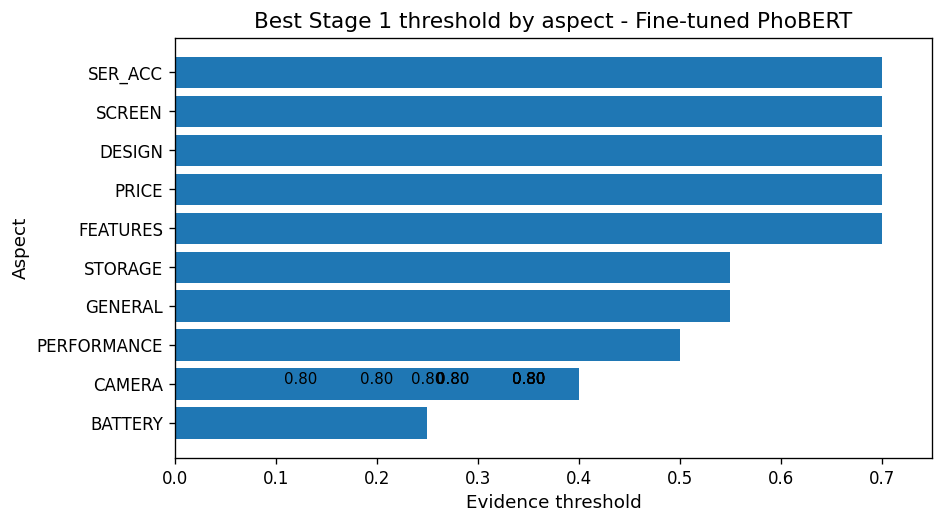

Saved: /content/report_figures/fine-tuned_phobert/05_stage1_threshold_by_aspect.png
Saved: /content/report_figures/fine-tuned_phobert/05_stage1_threshold_by_aspect.pdf


,aspect,threshold
0,BATTERY,0.25
1,CAMERA,0.40
5,PERFORMANCE,0.50
4,GENERAL,0.55
9,STORAGE,0.55
3,FEATURES,0.70
6,PRICE,0.70
2,DESIGN,0.70
7,SCREEN,0.70
8,SER_ACC,0.70


In [53]:
th_df = (
    pd.DataFrame(
        [{"aspect": k, "threshold": v} for k, v in EVIDENCE_THRESHOLDS_BY_ASPECT.items()]
    )
    .sort_values("threshold", ascending=True)
)

fig, ax = plt.subplots(figsize=(8, max(4, 0.45 * len(th_df))))
ax.barh(th_df["aspect"], th_df["threshold"])
ax.set_xlim(0, max(0.75, float(th_df["threshold"].max()) + 0.05))
ax.set_title(f"Best Stage 1 threshold by aspect - {RUN_NAME}")
ax.set_xlabel("Evidence threshold")
ax.set_ylabel("Aspect")
add_bar_labels(ax, fmt="{:.2f}")

save_fig("05_stage1_threshold_by_aspect")

th_df.to_csv(FIG_DIR / "stage1_threshold_by_aspect.csv", index=False)
th_df

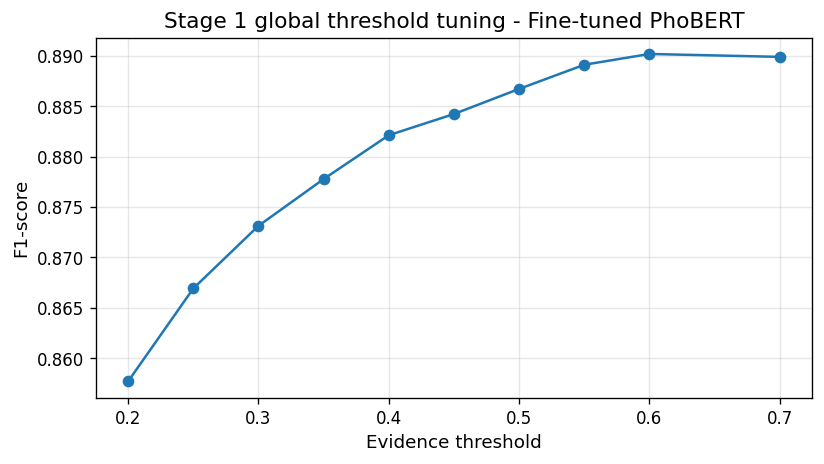

Saved: /content/report_figures/fine-tuned_phobert/06_stage1_global_threshold_curve.png
Saved: /content/report_figures/fine-tuned_phobert/06_stage1_global_threshold_curve.pdf


,mode,aspect,threshold,precision,recall,f1,tp,fp,fn
0,global,ALL,0.20,0.778205,0.955304,0.857708,3035,865,142
1,global,ALL,0.25,0.798357,0.948379,0.866926,3013,761,164
2,global,ALL,0.30,0.813366,0.942398,0.873141,2994,687,183
3,global,ALL,0.35,0.825568,0.937048,0.877783,2977,629,200
4,global,ALL,0.40,0.837578,0.931697,0.882134,2960,574,217
5,global,ALL,0.45,0.847374,0.924457,0.884239,2937,529,240
6,global,ALL,0.50,0.856556,0.919106,0.886729,2920,489,257
7,global,ALL,0.55,0.868066,0.911237,0.889128,2895,440,282
8,global,ALL,0.60,0.876220,0.904627,0.890197,2874,406,303
9,global,ALL,0.70,0.894436,0.885427,0.889908,2813,332,364


In [54]:
global_th_df = threshold_df[
    (threshold_df["mode"] == "global") & (threshold_df["aspect"] == "ALL")
].sort_values("threshold")

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(global_th_df["threshold"], global_th_df["f1"], marker="o")
ax.set_title(f"Stage 1 global threshold tuning - {RUN_NAME}")
ax.set_xlabel("Evidence threshold")
ax.set_ylabel("F1-score")
ax.grid(True, alpha=0.3)

save_fig("06_stage1_global_threshold_curve")

global_th_df.to_csv(FIG_DIR / "stage1_global_threshold_curve.csv", index=False)
global_th_df

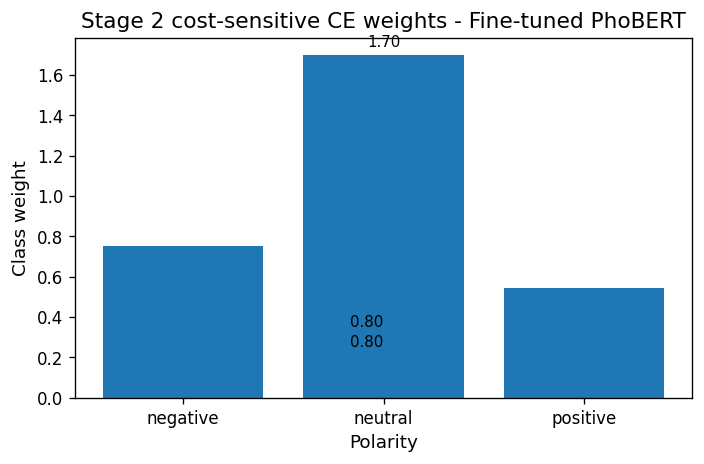

Saved: /content/report_figures/fine-tuned_phobert/07_stage2_class_weights.png
Saved: /content/report_figures/fine-tuned_phobert/07_stage2_class_weights.pdf


,polarity,ce_weight
0,negative,0.753150
1,neutral,1.700545
2,positive,0.546305


In [55]:
weights = STAGE2_CLASS_WEIGHTS.detach().cpu().numpy()

weight_df = pd.DataFrame({
    "polarity": get_label_order(),
    "ce_weight": weights,
})

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(weight_df["polarity"], weight_df["ce_weight"])
ax.set_title(f"Stage 2 cost-sensitive CE weights - {RUN_NAME}")
ax.set_xlabel("Polarity")
ax.set_ylabel("Class weight")
add_bar_labels(ax, fmt="{:.2f}")

save_fig("07_stage2_class_weights")

weight_df.to_csv(FIG_DIR / "stage2_class_weights.csv", index=False)
weight_df

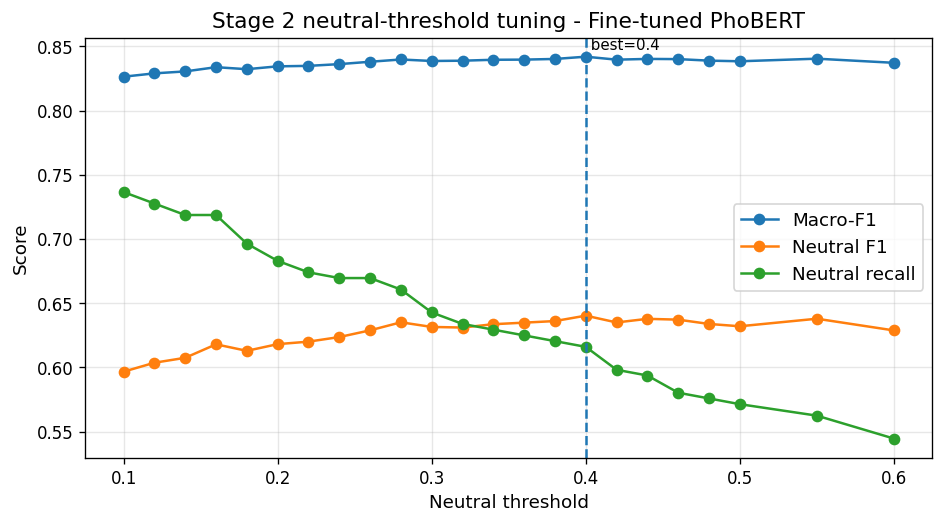

Saved: /content/report_figures/fine-tuned_phobert/08_stage2_neutral_threshold_curve.png
Saved: /content/report_figures/fine-tuned_phobert/08_stage2_neutral_threshold_curve.pdf


,neutral_threshold,macro_f1,weighted_f1,neutral_precision,neutral_recall,neutral_f1
0,0.10,0.826459,0.925488,0.501520,0.736607,0.596745
1,0.12,0.829051,0.925889,0.515823,0.727679,0.603704
2,0.14,0.830573,0.926211,0.526144,0.718750,0.607547
3,0.16,0.833869,0.926786,0.542088,0.718750,0.618042
4,0.18,0.832300,0.926833,0.547368,0.696429,0.612967
5,0.20,0.834520,0.927836,0.564576,0.683036,0.618182
6,0.22,0.834890,0.927730,0.574144,0.674107,0.620123
7,0.24,0.836246,0.928268,0.583658,0.669643,0.623701
8,0.26,0.838097,0.928624,0.592885,0.669643,0.628931
9,0.28,0.839855,0.928382,0.611570,0.660714,0.635193


In [56]:
nd = neutral_threshold_df.sort_values("neutral_threshold")

fig, ax = plt.subplots(figsize=(8, 4.5))

ax.plot(
    nd["neutral_threshold"],
    nd["macro_f1"],
    marker="o",
    label="Macro-F1",
)

ax.plot(
    nd["neutral_threshold"],
    nd["neutral_f1"],
    marker="o",
    label="Neutral F1",
)

ax.plot(
    nd["neutral_threshold"],
    nd["neutral_recall"],
    marker="o",
    label="Neutral recall",
)

ax.axvline(float(BEST_NEUTRAL_THRESHOLD), linestyle="--", linewidth=1.5)

ax.text(
    float(BEST_NEUTRAL_THRESHOLD),
    ax.get_ylim()[1],
    f" best={BEST_NEUTRAL_THRESHOLD}",
    va="top",
    fontsize=9,
)

ax.set_title(f"Stage 2 neutral-threshold tuning - {RUN_NAME}")
ax.set_xlabel("Neutral threshold")
ax.set_ylabel("Score")
ax.grid(True, alpha=0.3)
ax.legend()

save_fig("08_stage2_neutral_threshold_curve")

nd.to_csv(FIG_DIR / "stage2_neutral_threshold_tuning.csv", index=False)
nd

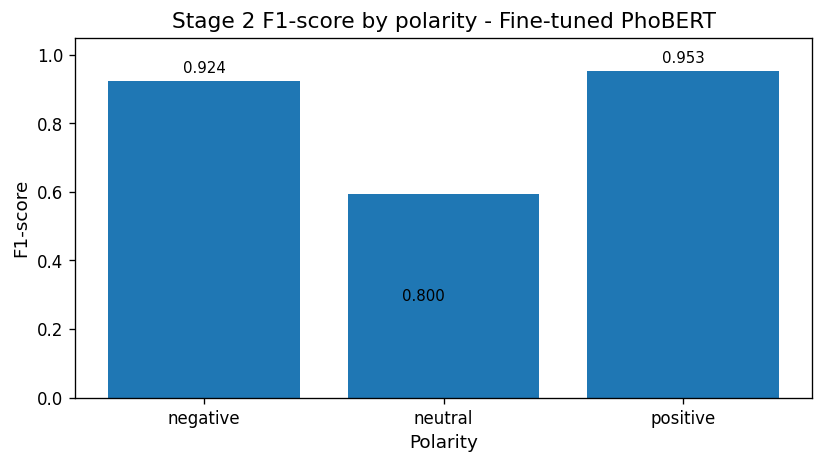

Saved: /content/report_figures/fine-tuned_phobert/09_stage2_f1_by_polarity.png
Saved: /content/report_figures/fine-tuned_phobert/09_stage2_f1_by_polarity.pdf


,polarity,precision,recall,f1-score,support
0,negative,0.941950,0.907383,0.924344,2289.0
1,neutral,0.675758,0.529691,0.593875,421.0
2,positive,0.934783,0.972536,0.953286,4333.0


In [57]:
label_order = get_label_order()

available_labels = [x for x in label_order if x in report_df.index]

f1_df = (
    report_df.loc[available_labels, ["precision", "recall", "f1-score", "support"]]
    .reset_index()
    .rename(columns={"index": "polarity"})
)

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(f1_df["polarity"], f1_df["f1-score"])
ax.set_ylim(0, 1.05)
ax.set_title(f"Stage 2 F1-score by polarity - {RUN_NAME}")
ax.set_xlabel("Polarity")
ax.set_ylabel("F1-score")
add_bar_labels(ax, fmt="{:.3f}")

save_fig("09_stage2_f1_by_polarity")

f1_df.to_csv(FIG_DIR / "stage2_classification_report.csv", index=False)
f1_df

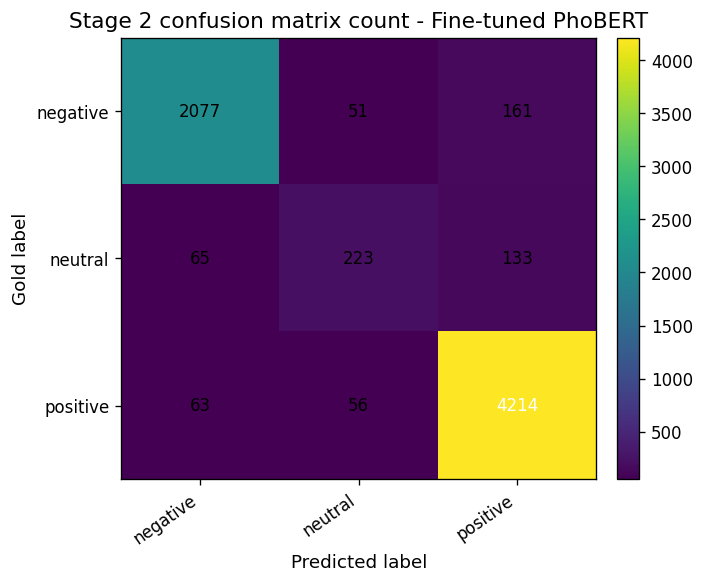

Saved: /content/report_figures/fine-tuned_phobert/10_stage2_confusion_matrix_count.png
Saved: /content/report_figures/fine-tuned_phobert/10_stage2_confusion_matrix_count.pdf


In [58]:
label_order = get_label_order()

if "cm" in globals():
    cm_arr = np.asarray(cm)
elif "cm_df" in globals():
    cm_arr = cm_df.values
else:
    raise ValueError("Không tìm thấy biến cm hoặc cm_df. Chạy cell evaluate Stage 2 trước.")

fig, ax = plt.subplots(figsize=(6, 5))

im = ax.imshow(cm_arr, interpolation="nearest", aspect="auto")
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

ax.set_title(f"Stage 2 confusion matrix count - {RUN_NAME}")
ax.set_xlabel("Predicted label")
ax.set_ylabel("Gold label")

ax.set_xticks(np.arange(len(label_order)))
ax.set_yticks(np.arange(len(label_order)))
ax.set_xticklabels(label_order, rotation=35, ha="right")
ax.set_yticklabels(label_order)

threshold = cm_arr.max() / 2.0

for i in range(cm_arr.shape[0]):
    for j in range(cm_arr.shape[1]):
        value = int(cm_arr[i, j])
        ax.text(
            j,
            i,
            str(value),
            ha="center",
            va="center",
            fontsize=10,
            color="white" if value > threshold else "black",
        )

save_fig("10_stage2_confusion_matrix_count")

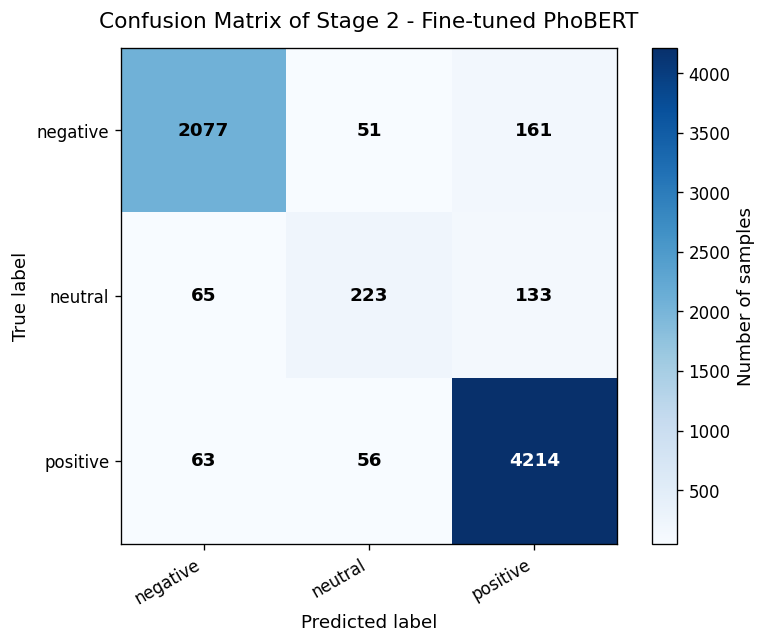

Saved: /content/report_figures/fine-tuned_phobert/stage2_confusion_matrix_report.png


In [59]:
label_order = get_label_order()

if "cm" in globals():
    cm_arr = np.asarray(cm)
elif "cm_df" in globals():
    cm_arr = cm_df.values
else:
    raise ValueError("Không tìm thấy biến cm hoặc cm_df. Hãy chạy phần evaluate Stage 2 trước.")

fig, ax = plt.subplots(figsize=(7, 5.5))

im = ax.imshow(cm_arr, cmap="Blues")
cbar = plt.colorbar(im, ax=ax)
cbar.ax.set_ylabel("Number of samples", rotation=90)

ax.set_title(f"Confusion Matrix of Stage 2 - {RUN_NAME}", pad=12)
ax.set_xlabel("Predicted label")
ax.set_ylabel("True label")

ax.set_xticks(np.arange(len(label_order)))
ax.set_yticks(np.arange(len(label_order)))
ax.set_xticklabels(label_order, rotation=30, ha="right")
ax.set_yticklabels(label_order)

thresh = cm_arr.max() / 2.0

for i in range(cm_arr.shape[0]):
    for j in range(cm_arr.shape[1]):
        ax.text(
            j, i, f"{cm_arr[i, j]:d}",
            ha="center", va="center",
            color="white" if cm_arr[i, j] > thresh else "black",
            fontsize=11, fontweight="bold"
        )

plt.tight_layout()

save_path = FIG_DIR / "stage2_confusion_matrix_report.png"
plt.savefig(save_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", save_path)

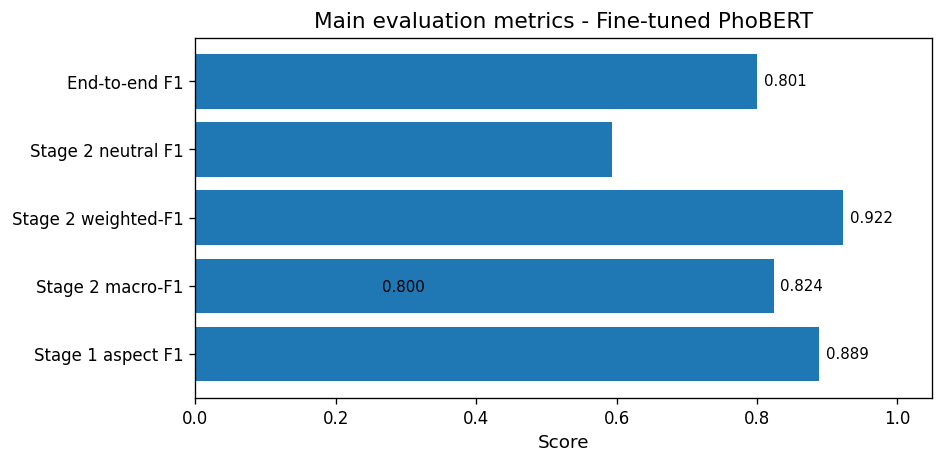

Saved: /content/report_figures/fine-tuned_phobert/12_main_metrics_summary.png
Saved: /content/report_figures/fine-tuned_phobert/12_main_metrics_summary.pdf


,metric,score
0,Stage 1 aspect F1,0.888749
1,Stage 2 macro-F1,0.823835
2,Stage 2 weighted-F1,0.922395
3,Stage 2 neutral F1,0.593875
4,End-to-end F1,0.800805


In [60]:
summary_rows = []

if "stage1_test_metrics" in globals():
    summary_rows.append({
        "metric": "Stage 1 aspect F1",
        "score": float(stage1_test_metrics.get("f1", np.nan)),
    })

if "report_df" in globals():
    if "macro avg" in report_df.index:
        summary_rows.append({
            "metric": "Stage 2 macro-F1",
            "score": float(report_df.loc["macro avg", "f1-score"]),
        })

    if "weighted avg" in report_df.index:
        summary_rows.append({
            "metric": "Stage 2 weighted-F1",
            "score": float(report_df.loc["weighted avg", "f1-score"]),
        })

    if "neutral" in report_df.index:
        summary_rows.append({
            "metric": "Stage 2 neutral F1",
            "score": float(report_df.loc["neutral", "f1-score"]),
        })

if "end2end_metrics" in globals():
    summary_rows.append({
        "metric": "End-to-end F1",
        "score": float(end2end_metrics.get("f1", np.nan)),
    })

metric_df = pd.DataFrame(summary_rows).dropna()

fig, ax = plt.subplots(figsize=(8, max(4, 0.5 * len(metric_df))))
ax.barh(metric_df["metric"], metric_df["score"])
ax.set_xlim(0, 1.05)
ax.set_title(f"Main evaluation metrics - {RUN_NAME}")
ax.set_xlabel("Score")
ax.set_ylabel("")
add_bar_labels(ax, fmt="{:.3f}")

save_fig("12_main_metrics_summary")

metric_df.to_csv(FIG_DIR / "main_metrics_summary.csv", index=False)
metric_df

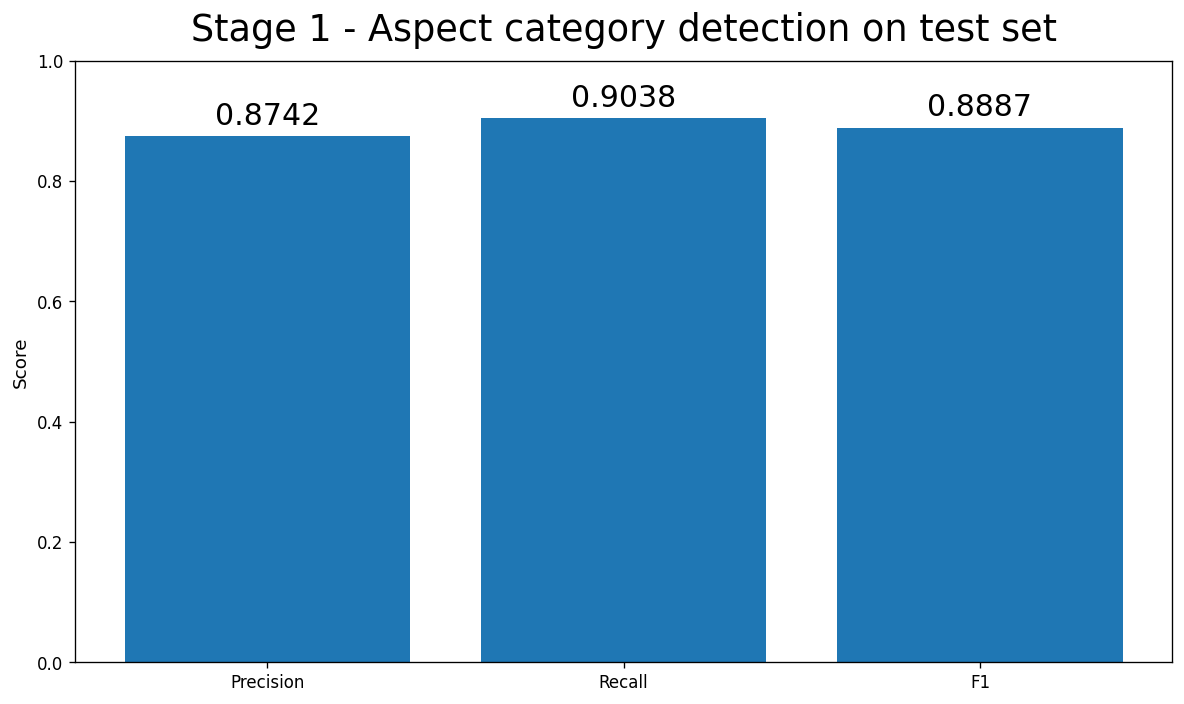

Saved: /content/report_figures/fine-tuned_phobert/stage1_test_metrics.png
Saved: /content/report_figures/fine-tuned_phobert/stage1_test_metrics.pdf


In [61]:
stage1_metric_names = ["Precision", "Recall", "F1"]
stage1_metric_values = [
    float(stage1_test_metrics["precision"]),
    float(stage1_test_metrics["recall"]),
    float(stage1_test_metrics["f1"]),
]

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(stage1_metric_names, stage1_metric_values)

ax.set_ylim(0, 1.0)
ax.set_ylabel("Score")
ax.set_title("Stage 1 - Aspect category detection on test set", fontsize=22, pad=12)

for bar, value in zip(bars, stage1_metric_values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        value + 0.01,
        f"{value:.4f}",
        ha="center",
        va="bottom",
        fontsize=18
    )

save_fig("stage1_test_metrics")

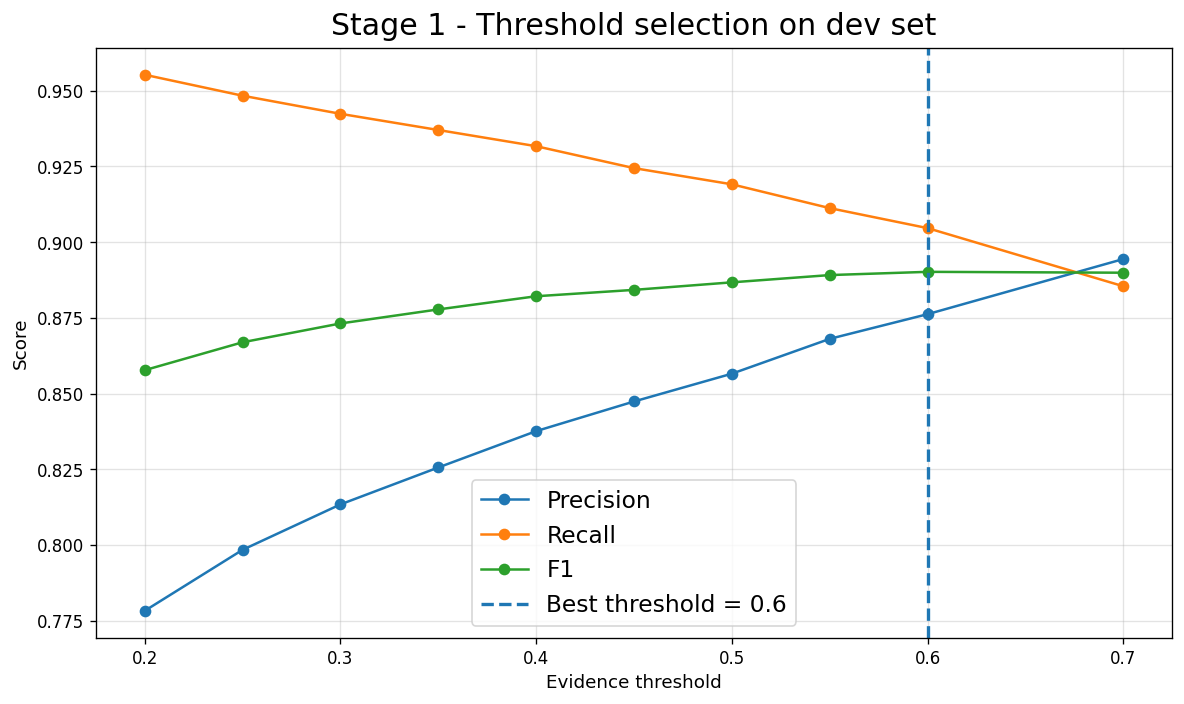

Saved: /content/report_figures/fine-tuned_phobert/stage1_threshold_selection.png
Saved: /content/report_figures/fine-tuned_phobert/stage1_threshold_selection.pdf


In [62]:
global_th_df = threshold_df[
    (threshold_df["mode"] == "global") & (threshold_df["aspect"] == "ALL")
].sort_values("threshold")

best_row = global_th_df.loc[global_th_df["f1"].idxmax()]
best_threshold = float(best_row["threshold"])

fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(global_th_df["threshold"], global_th_df["precision"], marker="o", label="Precision")
ax.plot(global_th_df["threshold"], global_th_df["recall"], marker="o", label="Recall")
ax.plot(global_th_df["threshold"], global_th_df["f1"], marker="o", label="F1")

ax.axvline(
    best_threshold,
    linestyle="--",
    linewidth=2,
    label=f"Best threshold = {best_threshold}"
)

ax.set_title("Stage 1 - Threshold selection on dev set", fontsize=18, pad=8)
ax.set_xlabel("Evidence threshold")
ax.set_ylabel("Score")
ax.grid(True, alpha=0.35)
ax.legend(fontsize=14)

save_fig("stage1_threshold_selection")

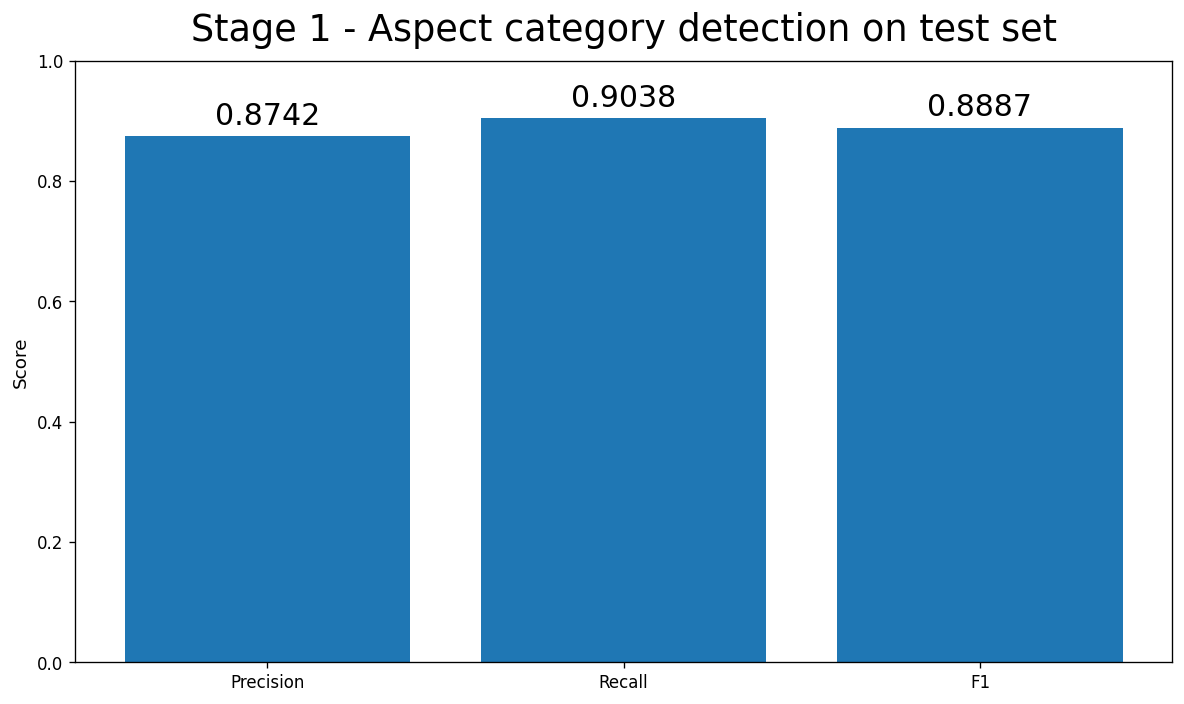

Saved: /content/report_figures/fine-tuned_phobert/stage1_test_metrics.png
Saved: /content/report_figures/fine-tuned_phobert/stage1_test_metrics.pdf


In [63]:
metric_names = ["Precision", "Recall", "F1"]
metric_values = [
    float(stage1_test_metrics["precision"]),
    float(stage1_test_metrics["recall"]),
    float(stage1_test_metrics["f1"]),
]

fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.bar(metric_names, metric_values)

ax.set_ylim(0, 1.0)
ax.set_ylabel("Score")
ax.set_title("Stage 1 - Aspect category detection on test set", fontsize=22, pad=12)

for bar, value in zip(bars, metric_values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        value + 0.01,
        f"{value:.4f}",
        ha="center",
        va="bottom",
        fontsize=18
    )

save_fig("stage1_test_metrics")

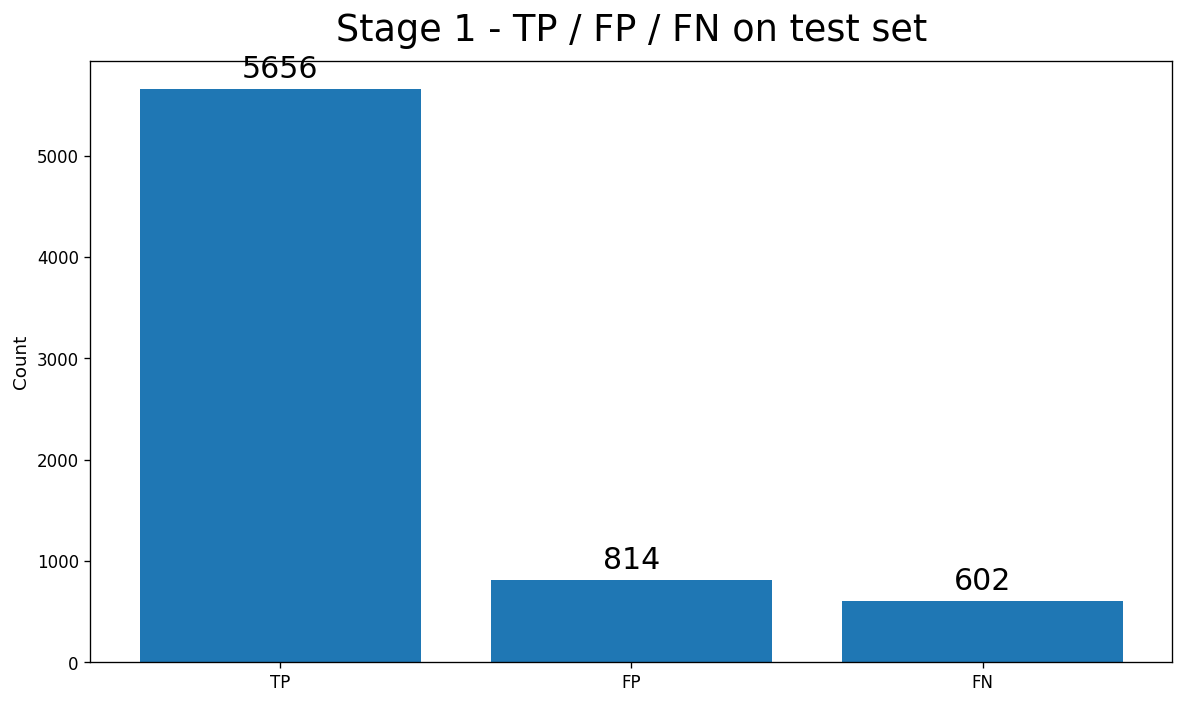

Saved: /content/report_figures/fine-tuned_phobert/stage1_tp_fp_fn.png
Saved: /content/report_figures/fine-tuned_phobert/stage1_tp_fp_fn.pdf


In [64]:
names = ["TP", "FP", "FN"]
values = [
    int(stage1_test_metrics["tp"]),
    int(stage1_test_metrics["fp"]),
    int(stage1_test_metrics["fn"]),
]

fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.bar(names, values)

ax.set_ylabel("Count")
ax.set_title("Stage 1 - TP / FP / FN on test set", fontsize=22, pad=12)

for bar, value in zip(bars, values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        value + max(values) * 0.01,
        f"{value}",
        ha="center",
        va="bottom",
        fontsize=18
    )

save_fig("stage1_tp_fp_fn")

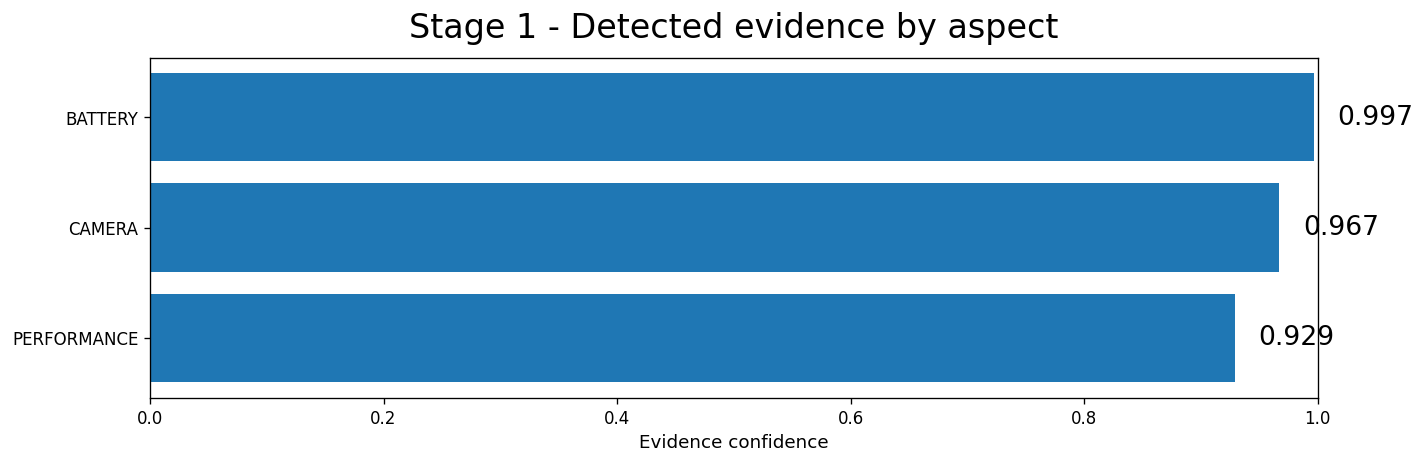

Saved: /content/report_figures/fine-tuned_phobert/stage1_evidence_example.png
Saved: /content/report_figures/fine-tuned_phobert/stage1_evidence_example.pdf


In [65]:
sample_text = "Pin trâu, máy mượt, phục vụ ổn nhưng tính năng camera chưa thật sự nổi bật."

pred_items = predict_evidence_masks(
    sample_text,
    threshold=EVIDENCE_THRESHOLDS_BY_ASPECT
)

evidence_rows = []

for item in pred_items:
    conf = float(item.get("confidence", 0.0))
    if conf > 0:
        evidence_rows.append({
            "aspect": item["category"],
            "confidence": conf,
        })

evidence_df = pd.DataFrame(evidence_rows)

if len(evidence_df) == 0:
    raise ValueError("Không detect được evidence nào. Đổi sample_text khác.")

evidence_df = evidence_df.sort_values("confidence", ascending=True).tail(6)

fig, ax = plt.subplots(figsize=(12, 4))

bars = ax.barh(evidence_df["aspect"], evidence_df["confidence"])

ax.set_xlim(0, 1.0)
ax.set_xlabel("Evidence confidence")
ax.set_title("Stage 1 - Detected evidence by aspect", fontsize=20, pad=12)

for bar, value in zip(bars, evidence_df["confidence"]):
    ax.text(
        value + 0.02,
        bar.get_y() + bar.get_height() / 2,
        f"{value:.3f}",
        va="center",
        fontsize=16
    )

save_fig("stage1_evidence_example")

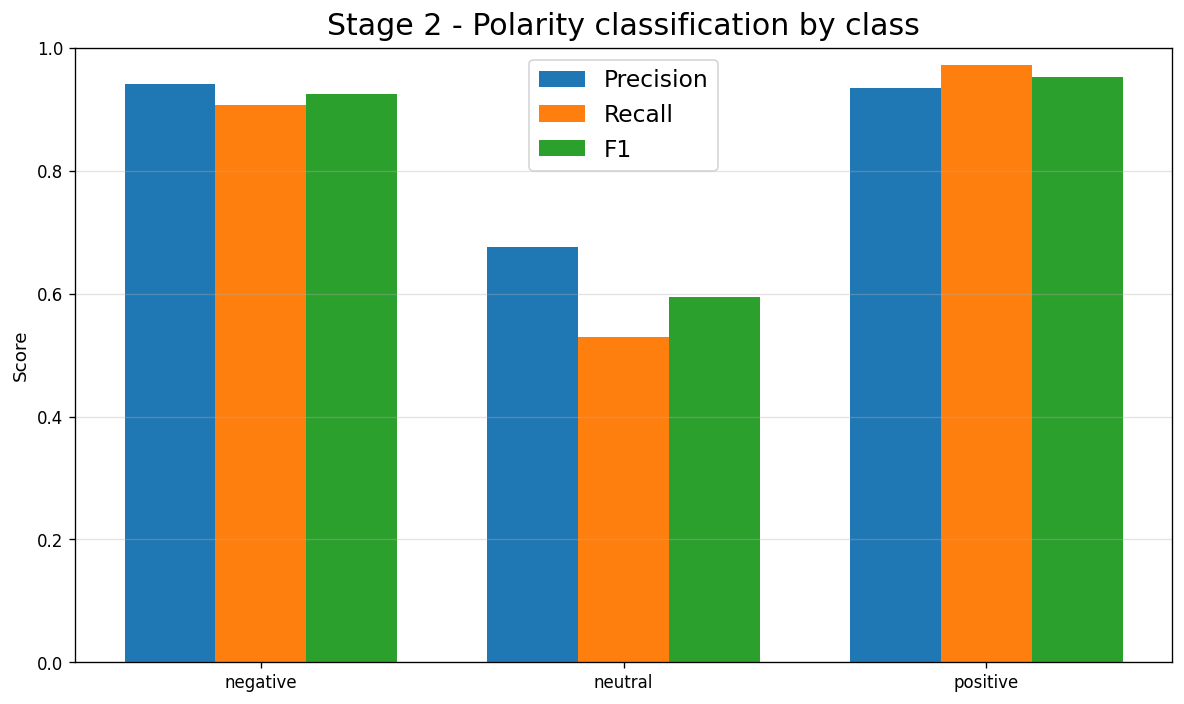

Saved: /content/report_figures/fine-tuned_phobert/stage2_polarity_metrics.png
Saved: /content/report_figures/fine-tuned_phobert/stage2_polarity_metrics.pdf


In [66]:
labels = get_label_order()

precision_vals = [float(report_df.loc[label, "precision"]) for label in labels]
recall_vals = [float(report_df.loc[label, "recall"]) for label in labels]
f1_vals = [float(report_df.loc[label, "f1-score"]) for label in labels]

x = np.arange(len(labels))
width = 0.25

fig, ax = plt.subplots(figsize=(10, 6))

ax.bar(x - width, precision_vals, width, label="Precision")
ax.bar(x, recall_vals, width, label="Recall")
ax.bar(x + width, f1_vals, width, label="F1")

ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylim(0, 1.0)
ax.set_ylabel("Score")
ax.set_title("Stage 2 - Polarity classification by class", fontsize=18, pad=8)
ax.grid(True, axis="y", alpha=0.35)
ax.legend(fontsize=14)

save_fig("stage2_polarity_metrics")

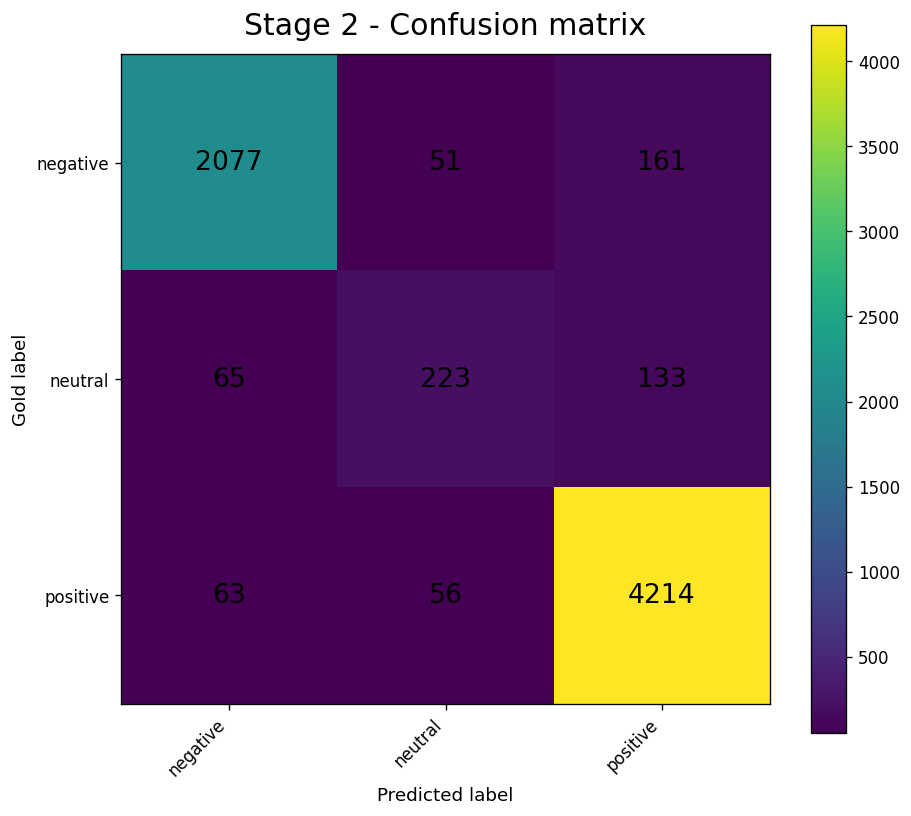

Saved: /content/report_figures/fine-tuned_phobert/stage2_confusion_matrix.png
Saved: /content/report_figures/fine-tuned_phobert/stage2_confusion_matrix.pdf


In [67]:
labels = get_label_order()

if "cm" in globals():
    cm_arr = np.asarray(cm)
elif "cm_df" in globals():
    cm_arr = cm_df.values
else:
    raise ValueError("Không tìm thấy biến cm hoặc cm_df. Chạy evaluate Stage 2 trước.")

fig, ax = plt.subplots(figsize=(8, 7))

im = ax.imshow(cm_arr, interpolation="nearest")
plt.colorbar(im, ax=ax)

ax.set_title("Stage 2 - Confusion matrix", fontsize=18, pad=12)
ax.set_xlabel("Predicted label")
ax.set_ylabel("Gold label")

ax.set_xticks(np.arange(len(labels)))
ax.set_yticks(np.arange(len(labels)))
ax.set_xticklabels(labels, rotation=45, ha="right")
ax.set_yticklabels(labels)

for i in range(cm_arr.shape[0]):
    for j in range(cm_arr.shape[1]):
        ax.text(
            j,
            i,
            f"{int(cm_arr[i, j])}",
            ha="center",
            va="center",
            color="black",
            fontsize=16
        )

save_fig("stage2_confusion_matrix")

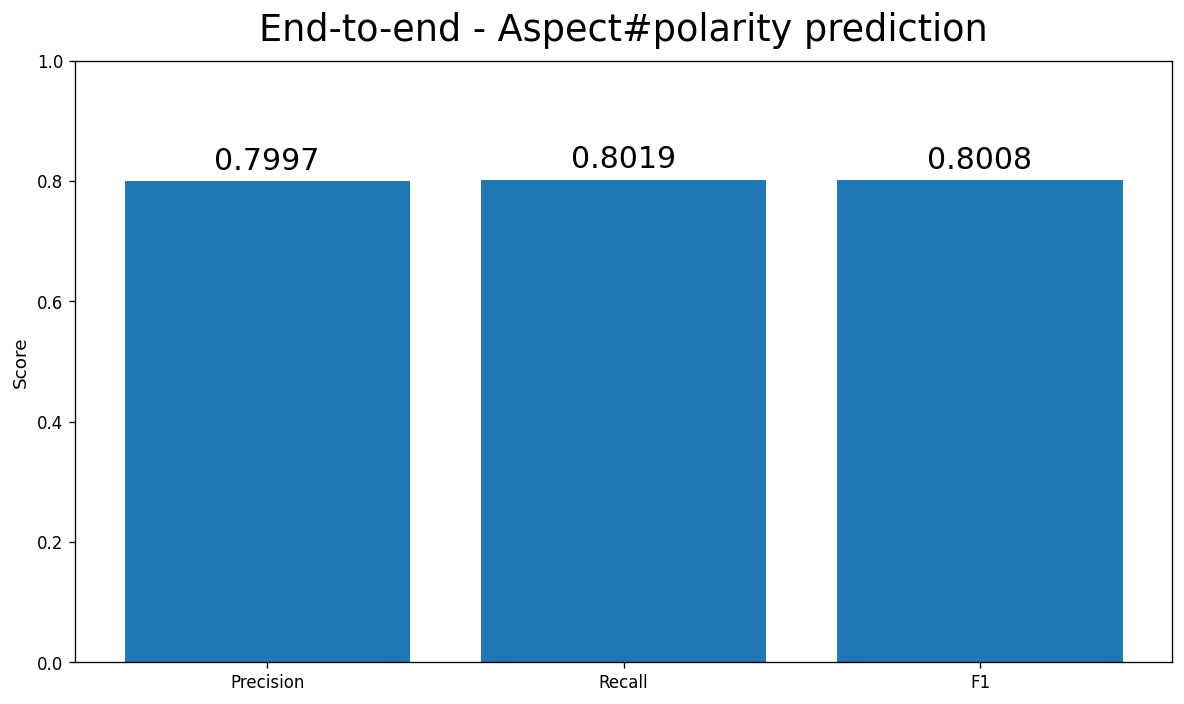

Saved: /content/report_figures/fine-tuned_phobert/end_to_end_metrics.png
Saved: /content/report_figures/fine-tuned_phobert/end_to_end_metrics.pdf


In [68]:
metric_names = ["Precision", "Recall", "F1"]
metric_values = [
    float(end2end_metrics["precision"]),
    float(end2end_metrics["recall"]),
    float(end2end_metrics["f1"]),
]

fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.bar(metric_names, metric_values)

ax.set_ylim(0, 1.0)
ax.set_ylabel("Score")
ax.set_title("End-to-end - Aspect#polarity prediction", fontsize=22, pad=12)

for bar, value in zip(bars, metric_values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        value + 0.01,
        f"{value:.4f}",
        ha="center",
        va="bottom",
        fontsize=18
    )

save_fig("end_to_end_metrics")

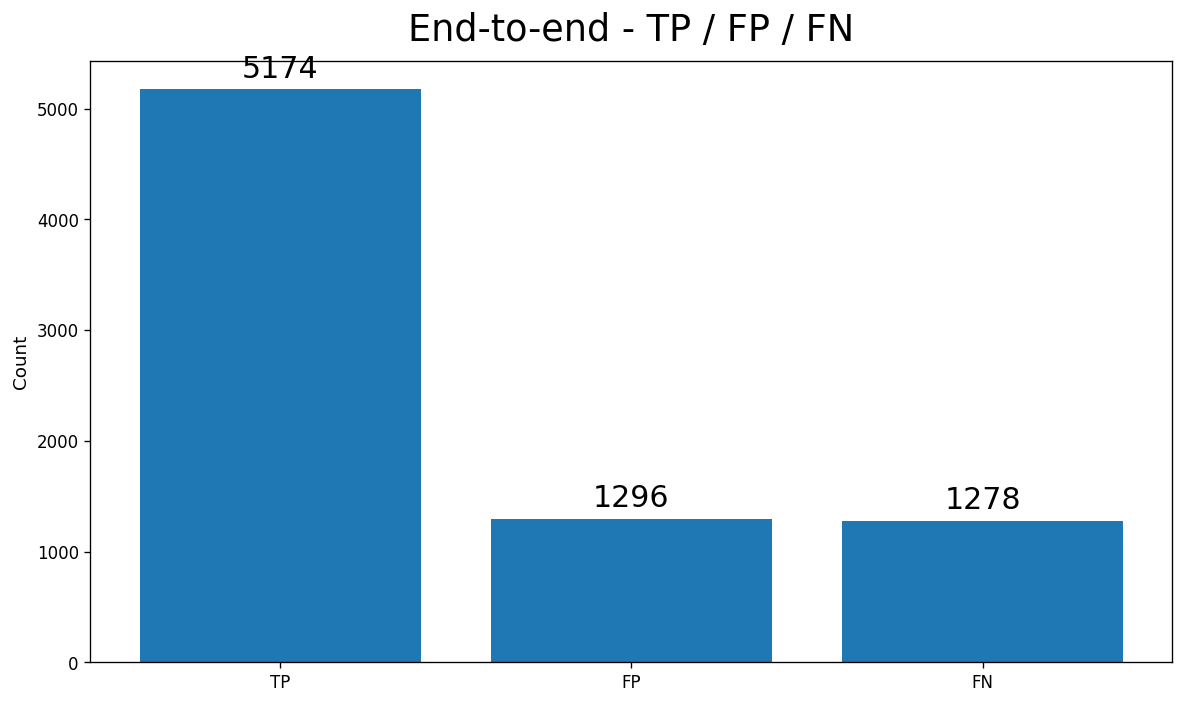

Saved: /content/report_figures/fine-tuned_phobert/end_to_end_tp_fp_fn.png
Saved: /content/report_figures/fine-tuned_phobert/end_to_end_tp_fp_fn.pdf


In [69]:
names = ["TP", "FP", "FN"]
values = [
    int(end2end_metrics["tp"]),
    int(end2end_metrics["fp"]),
    int(end2end_metrics["fn"]),
]

fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.bar(names, values)

ax.set_ylabel("Count")
ax.set_title("End-to-end - TP / FP / FN", fontsize=22, pad=12)

for bar, value in zip(bars, values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        value + max(values) * 0.01,
        f"{value}",
        ha="center",
        va="bottom",
        fontsize=18
    )

save_fig("end_to_end_tp_fp_fn")

In [70]:
import os
import shutil
from datetime import datetime

#Cấu hình tên và đường dẫn xuất
ZIP_BASE_NAME = "Vietnamese_ABSA_Pipeline_Final"
EXPORT_ROOT = "/content/export_pipeline_absa"
# Đảm bảo folder name khớp với yêu cầu của bạn
CHECKPOINTS_DIR = os.path.join(EXPORT_ROOT, "checkpoints/absa_phobert_bilstm_tclstm")
OUTPUTS_DIR = os.path.join(EXPORT_ROOT, "outputs/absa_phobert_bilstm_tclstm")

# Tạo cấu trúc thư mục
os.makedirs(CHECKPOINTS_DIR, exist_ok=True)
os.makedirs(OUTPUTS_DIR, exist_ok=True)

#Copy file trọng số (Sửa lỗi: thêm đuôi .pt để khớp với cell a32f862d)
if os.path.exists(model_path):
    shutil.copy(model_path, os.path.join(CHECKPOINTS_DIR, "absa_phobert_bilstm_tclstm.pt"))

#Copy các file ảnh và CSV kết quả từ FIG_DIR
if os.path.exists(FIG_DIR):
    for item in os.listdir(FIG_DIR):
        s = os.path.join(FIG_DIR, item)
        d = os.path.join(OUTPUTS_DIR, item)
        if os.path.isdir(s):
            shutil.copytree(s, d, dirs_exist_ok=True)
        else:
            shutil.copy2(s, d)

#Nén thành zip
timestamp = datetime.now().strftime('%Y%m%d_%H%M')
final_zip_name = f"{ZIP_BASE_NAME}_{timestamp}"
shutil.make_archive(f"/content/{final_zip_name}", 'zip', EXPORT_ROOT)

#Lưu vào Google Drive
try:
    drive_path = f"/content/drive/MyDrive/{final_zip_name}.zip"
    shutil.copy(f"/content/{final_zip_name}.zip", drive_path)
    print(f"✅ Đã sao lưu vào Google Drive: {drive_path}")
except Exception as e:
    print(f"⚠️ Không thể lưu vào Drive (Có thể chưa mount): {e}")

print(f"✅ Đã tạo file zip thành công tại: /content/{final_zip_name}.zip")

✅ Đã sao lưu vào Google Drive: /content/drive/MyDrive/Vietnamese_ABSA_Pipeline_Final_20260630_1013.zip
✅ Đã tạo file zip thành công tại: /content/Vietnamese_ABSA_Pipeline_Final_20260630_1013.zip
